# 🚗 KAPSAMLI VEHICLE SALES DATA SCIENCE ANALİZİ
## Bir Data Scientist'in Yapabileceği TÜM Analizler

Bu notebook, vehicle sales verisi üzerinde:
- ✅ Data Loading & Initial Exploration
- ✅ Data Cleaning & Preprocessing  
- ✅ Exploratory Data Analysis (EDA)
- ✅ Advanced Visualizations
- ✅ Feature Engineering
- ✅ Statistical Testing
- ✅ Time Series Analysis
- ✅ Machine Learning Models
- ✅ Model Evaluation & Interpretation
- ✅ Business Insights

## 📚 1. KÜTÜPHANE YÜKLEMELERİ

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Statistical analysis
from scipy import stats
from scipy.stats import normaltest, shapiro, kstest, chi2_contingency

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Tüm kütüphaneler başarıyla yüklendi!")

✅ Tüm kütüphaneler başarıyla yüklendi!


## 📊 2. VERİ YÜKLEME VE İLK KEŞİF

In [3]:
# Veriyi yükle
df = pd.read_csv('/content/sample_data/vehicle_sales_data.csv')

print("="*80)
print("DATASET GENEL BİLGİLERİ")
print("="*80)
print(f"\n📌 Toplam Satır Sayısı: {df.shape[0]:,}")
print(f"📌 Toplam Sütun Sayısı: {df.shape[1]}")
print(f"📌 Toplam Veri Noktası: {df.shape[0] * df.shape[1]:,}")
print(f"📌 Bellek Kullanımı: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# İlk 5 satır
print("\n" + "="*80)
print("İLK 5 SATIR")
print("="*80)
df.head()

DATASET GENEL BİLGİLERİ

📌 Toplam Satır Sayısı: 5,000
📌 Toplam Sütun Sayısı: 14
📌 Toplam Veri Noktası: 70,000
📌 Bellek Kullanımı: 2.76 MB

İLK 5 SATIR


,year,brand,model,condition,mileage,color,body_type,fuel_type,transmission,engine_size,price,sale_date,seller_type,state
0,2016,Honda,Civic,Used,61022.0,Black,Hatchback,Electric,Automatic,1.6,15131.18,2021-03-23,Private,NC
1,2013,Kia,Forte,New,70.0,Green,SUV,Electric,CVT,2.5,22205.34,2020-01-14,Private,OH
2,2022,Mercedes,GLC,New,76.0,Black,Sedan,Electric,Automatic,2.8,59278.23,2021-12-05,Dealer,CA
3,2020,Nissan,Altima,Used,37201.0,Red,Hatchback,Diesel,CVT,1.7,17119.28,2023-09-16,Private,PA
4,2017,Honda,Accord,New,45.0,Red,SUV,Hybrid,Manual,2.2,26938.30,2021-06-30,Dealer,MI


In [4]:
# Dataset info
print("="*80)
print("DATASET BİLGİLERİ")
print("="*80)
df.info()

DATASET BİLGİLERİ
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   year          5000 non-null   int64  
 1   brand         5000 non-null   object 
 2   model         5000 non-null   object 
 3   condition     5000 non-null   object 
 4   mileage       4967 non-null   float64
 5   color         4966 non-null   object 
 6   body_type     5000 non-null   object 
 7   fuel_type     5000 non-null   object 
 8   transmission  5000 non-null   object 
 9   engine_size   4967 non-null   float64
 10  price         5000 non-null   float64
 11  sale_date     5000 non-null   object 
 12  seller_type   5000 non-null   object 
 13  state         5000 non-null   object 
dtypes: float64(3), int64(1), object(10)
memory usage: 547.0+ KB


In [5]:
# Sütun tipleri
print("="*80)
print("SÜTUN TİPLERİ")
print("="*80)
print(df.dtypes)

SÜTUN TİPLERİ
year              int64
brand            object
model            object
condition        object
mileage         float64
color            object
body_type        object
fuel_type        object
transmission     object
engine_size     float64
price           float64
sale_date        object
seller_type      object
state            object
dtype: object


In [6]:
# Eksik değer analizi
print("="*80)
print("EKSİK DEĞER ANALİZİ")
print("="*80)

missing_data = pd.DataFrame({
    'Sütun': df.columns,
    'Eksik_Sayısı': df.isnull().sum(),
    'Eksik_Yüzdesi': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Eksik_Sayısı', ascending=False)

missing_data = missing_data[missing_data['Eksik_Sayısı'] > 0]
print(missing_data)

EKSİK DEĞER ANALİZİ
                   Sütun  Eksik_Sayısı  Eksik_Yüzdesi
color              color            34           0.68
mileage          mileage            33           0.66
engine_size  engine_size            33           0.66


In [7]:
# Duplicate analizi
print("="*80)
print("DUPLICATE ANALİZİ")
print("="*80)
duplicates = df.duplicated().sum()
print(f"\n📌 Duplicate Satır Sayısı: {duplicates}")
print(f"📌 Duplicate Yüzdesi: {(duplicates/len(df)*100):.2f}%")

DUPLICATE ANALİZİ

📌 Duplicate Satır Sayısı: 0
📌 Duplicate Yüzdesi: 0.00%


## 🧹 3. VERİ TEMİZLEME VE ÖNİŞLEME

In [8]:
# Sale date'i datetime'a çevir
df['sale_date'] = pd.to_datetime(df['sale_date'])

# Eksik değerleri doldur
print("🔧 Eksik değerler dolduruluyor...")

# Mileage için median
df['mileage'].fillna(df.groupby(['condition', 'year'])['mileage'].transform('median'), inplace=True)

# Engine size için median
df['engine_size'].fillna(df['engine_size'].median(), inplace=True)

# Color için mode
df['color'].fillna(df['color'].mode()[0], inplace=True)

print("✅ Tüm eksik değerler dolduruldu!")
print(f"\nKalan eksik değer sayısı: {df.isnull().sum().sum()}")

🔧 Eksik değerler dolduruluyor...
✅ Tüm eksik değerler dolduruldu!

Kalan eksik değer sayısı: 0


In [9]:
# Feature Engineering - Yeni değişkenler oluştur
print("🔧 Feature Engineering yapılıyor...\n")

# 1. Vehicle Age
df['vehicle_age'] = 2023 - df['year']
print("✅ vehicle_age oluşturuldu")

# 2. Price per Year (Yıllık Değer Kaybı)
df['price_per_year'] = df['price'] / (df['vehicle_age'] + 1)
print("✅ price_per_year oluşturuldu")

# 3. Mileage per Year
df['mileage_per_year'] = df['mileage'] / (df['vehicle_age'] + 1)
print("✅ mileage_per_year oluşturuldu")

# 4. Sale year, month, quarter
df['sale_year'] = df['sale_date'].dt.year
df['sale_month'] = df['sale_date'].dt.month
df['sale_quarter'] = df['sale_date'].dt.quarter
df['sale_day_of_week'] = df['sale_date'].dt.dayofweek
print("✅ Zaman bazlı özellikler oluşturuldu")

# 5. Price Categories
df['price_category'] = pd.cut(df['price'],
                               bins=[0, 15000, 25000, 40000, np.inf],
                               labels=['Budget', 'Mid-Range', 'Premium', 'Luxury'])
print("✅ price_category oluşturuldu")

# 6. Brand Tier (Luxury vs Non-Luxury)
luxury_brands = ['BMW', 'Mercedes', 'Audi']
df['is_luxury'] = df['brand'].isin(luxury_brands).astype(int)
print("✅ is_luxury oluşturuldu")

# 7. High Mileage Flag
df['high_mileage'] = (df['mileage'] > df['mileage'].quantile(0.75)).astype(int)
print("✅ high_mileage oluşturuldu")

print(f"\n🎉 Feature Engineering tamamlandı! Yeni sütun sayısı: {df.shape[1]}")

🔧 Feature Engineering yapılıyor...

✅ vehicle_age oluşturuldu
✅ price_per_year oluşturuldu
✅ mileage_per_year oluşturuldu
✅ Zaman bazlı özellikler oluşturuldu
✅ price_category oluşturuldu
✅ is_luxury oluşturuldu
✅ high_mileage oluşturuldu

🎉 Feature Engineering tamamlandı! Yeni sütun sayısı: 24


## 📈 4. DESCRIPTIVE STATISTICS (Tanımlayıcı İstatistikler)

In [10]:
# Sayısal değişkenler için istatistikler
print("="*80)
print("SAYISAL DEĞİŞKENLER - DETAYLI İSTATİSTİKLER")
print("="*80)

numeric_cols = df.select_dtypes(include=[np.number]).columns
stats_df = df[numeric_cols].describe().T

# Ek istatistikler ekle
stats_df['skewness'] = df[numeric_cols].skew()
stats_df['kurtosis'] = df[numeric_cols].kurtosis()
stats_df['variance'] = df[numeric_cols].var()

stats_df

SAYISAL DEĞİŞKENLER - DETAYLI İSTATİSTİKLER


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,variance
year,5000.0,2016.471000,4.054041,2010.000000,2013.000000,2016.000000,2020.000000,2023.000000,0.008286,-1.225284,1.643525e+01
mileage,5000.0,38235.672500,51952.614896,0.000000,44.000000,93.000000,73754.000000,194976.000000,1.109747,-0.066313,2.699074e+09
engine_size,5000.0,3.239920,1.000387,1.500000,2.400000,3.200000,4.100000,5.000000,0.033529,-1.167338,1.000775e+00
price,5000.0,26185.937694,13629.209987,6269.580000,15618.210000,24175.965000,31495.045000,70013.550000,0.948352,0.286137,1.857554e+08
vehicle_age,5000.0,6.529000,4.054041,0.000000,3.000000,7.000000,10.000000,13.000000,-0.008286,-1.225284,1.643525e+01
price_per_year,5000.0,6530.107557,8973.519301,447.827143,1837.661857,3378.367778,6836.077188,70013.550000,3.375275,14.053146,8.052405e+07
mileage_per_year,5000.0,4445.546262,4981.244345,0.000000,5.909091,37.500000,9291.916667,13926.857143,0.390702,-1.572691,2.481280e+07
sale_year,5000.0,2021.512600,1.108191,2020.000000,2021.000000,2022.000000,2022.000000,2023.000000,-0.012840,-1.337083,1.228087e+00
sale_month,5000.0,6.448000,3.434772,1.000000,3.000000,6.000000,9.000000,12.000000,0.015724,-1.201418,1.179766e+01
sale_quarter,5000.0,2.491400,1.115964,1.000000,1.000000,2.000000,3.000000,4.000000,0.009485,-1.355095,1.245375e+00


In [11]:
# Kategorik değişkenler için istatistikler
print("="*80)
print("KATEGORİK DEĞİŞKENLER - DETAYLI İSTATİSTİKLER")
print("="*80)

categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(f"\n📊 {col.upper()}:")
    print("-" * 60)
    value_counts = df[col].value_counts()
    percentages = df[col].value_counts(normalize=True) * 100

    result = pd.DataFrame({
        'Count': value_counts,
        'Percentage': percentages.round(2)
    })
    print(result)
    print(f"\nUnique Values: {df[col].nunique()}")

KATEGORİK DEĞİŞKENLER - DETAYLI İSTATİSTİKLER

📊 BRAND:
------------------------------------------------------------
           Count  Percentage
brand                       
BMW          529       10.58
Nissan       528       10.56
Kia          526       10.52
Audi         523       10.46
Honda        493        9.86
Ford         493        9.86
Hyundai      486        9.72
Mercedes     483        9.66
Toyota       481        9.62
Chevrolet    458        9.16

Unique Values: 10

📊 MODEL:
------------------------------------------------------------
            Count  Percentage
model                        
Altima        164        3.28
Tucson        157        3.14
Sportage      148        2.96
Pilot         143        2.86
Sentra        141        2.82
X5            141        2.82
Sorento       139        2.78
A6            139        2.78
RAV4          138        2.76
F-150         138        2.76
3 Series      132        2.64
Q7            131        2.62
A4            130        

## 📊 5. EXPLORATORY DATA ANALYSIS (EDA) - VİZUALİZASYONLAR

### 5.1 Univariate Analysis (Tek Değişken Analizi)

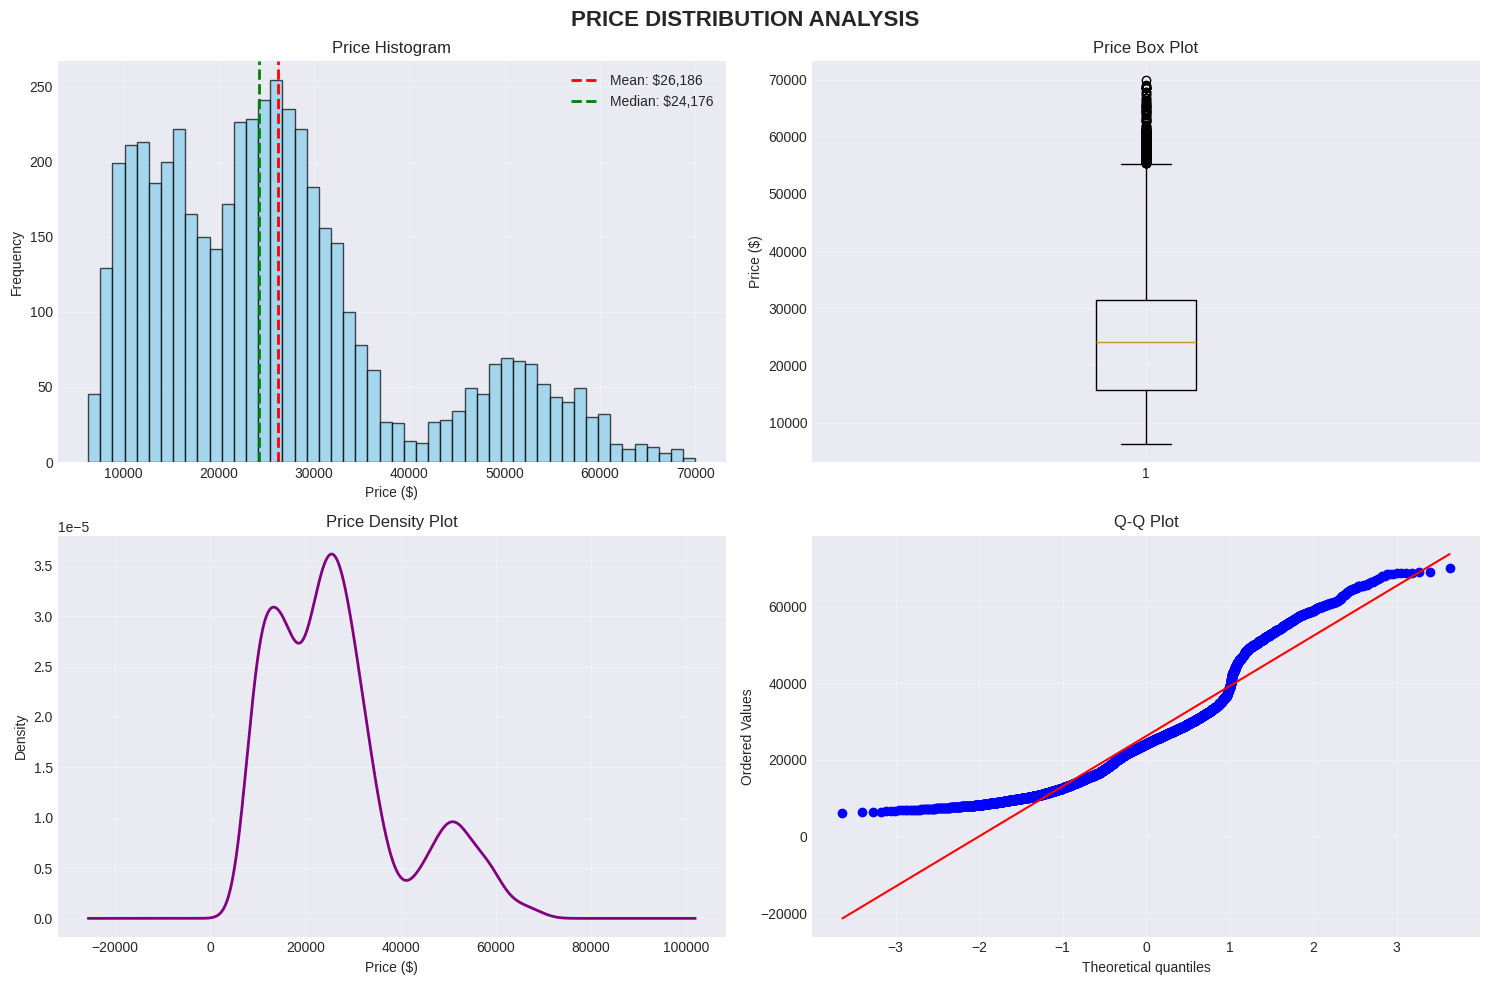


📊 PRICE İSTATİSTİKLERİ:
Skewness: 0.9484
Kurtosis: 0.2861


In [12]:
# Price Distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('PRICE DISTRIBUTION ANALYSIS', fontsize=16, fontweight='bold')

# Histogram
axes[0, 0].hist(df['price'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df['price'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${df["price"].mean():,.0f}')
axes[0, 0].axvline(df['price'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: ${df["price"].median():,.0f}')
axes[0, 0].set_title('Price Histogram')
axes[0, 0].set_xlabel('Price ($)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Box Plot
axes[0, 1].boxplot(df['price'], vert=True)
axes[0, 1].set_title('Price Box Plot')
axes[0, 1].set_ylabel('Price ($)')
axes[0, 1].grid(True, alpha=0.3)

# KDE Plot
df['price'].plot(kind='kde', ax=axes[1, 0], color='purple', linewidth=2)
axes[1, 0].set_title('Price Density Plot')
axes[1, 0].set_xlabel('Price ($)')
axes[1, 0].set_ylabel('Density')
axes[1, 0].grid(True, alpha=0.3)

# QQ Plot
stats.probplot(df['price'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Skewness ve Kurtosis
print(f"\n📊 PRICE İSTATİSTİKLERİ:")
print(f"Skewness: {df['price'].skew():.4f}")
print(f"Kurtosis: {df['price'].kurtosis():.4f}")

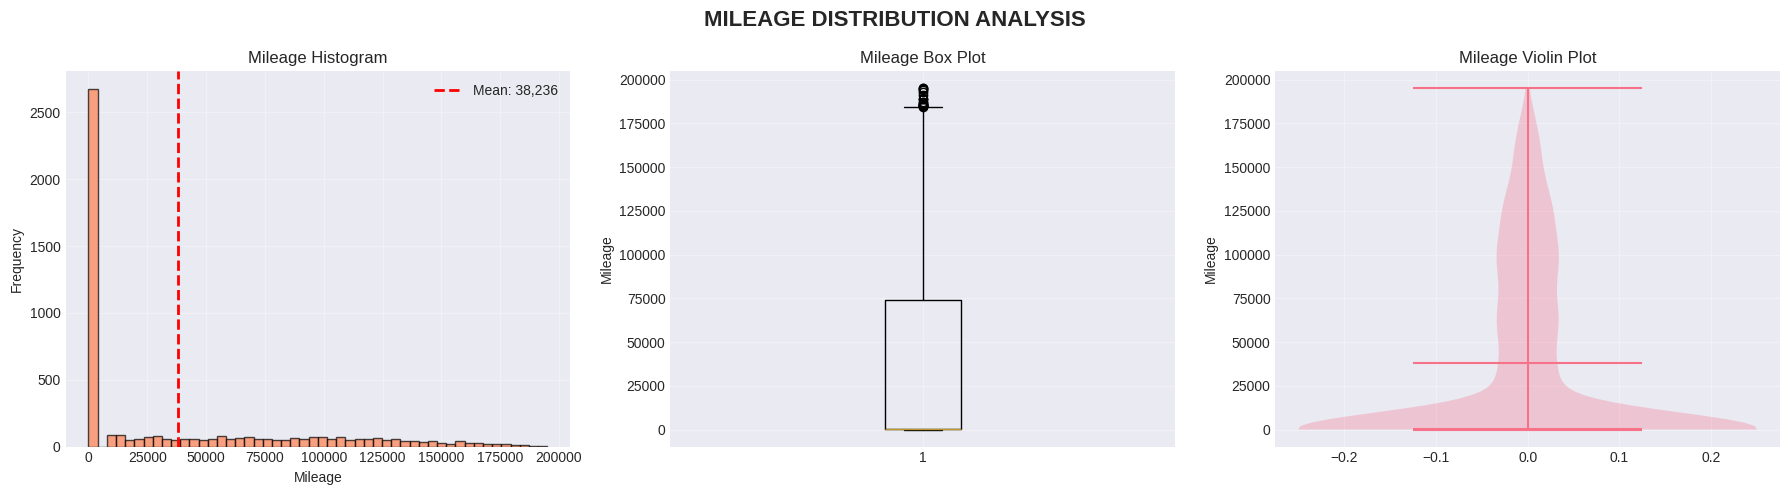

In [13]:
# Mileage Distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('MILEAGE DISTRIBUTION ANALYSIS', fontsize=16, fontweight='bold')

# Histogram
axes[0].hist(df['mileage'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0].axvline(df['mileage'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["mileage"].mean():,.0f}')
axes[0].set_title('Mileage Histogram')
axes[0].set_xlabel('Mileage')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box Plot
axes[1].boxplot(df['mileage'])
axes[1].set_title('Mileage Box Plot')
axes[1].set_ylabel('Mileage')
axes[1].grid(True, alpha=0.3)

# Violin Plot
parts = axes[2].violinplot([df['mileage'].dropna()], positions=[0], showmeans=True, showmedians=True)
axes[2].set_title('Mileage Violin Plot')
axes[2].set_ylabel('Mileage')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

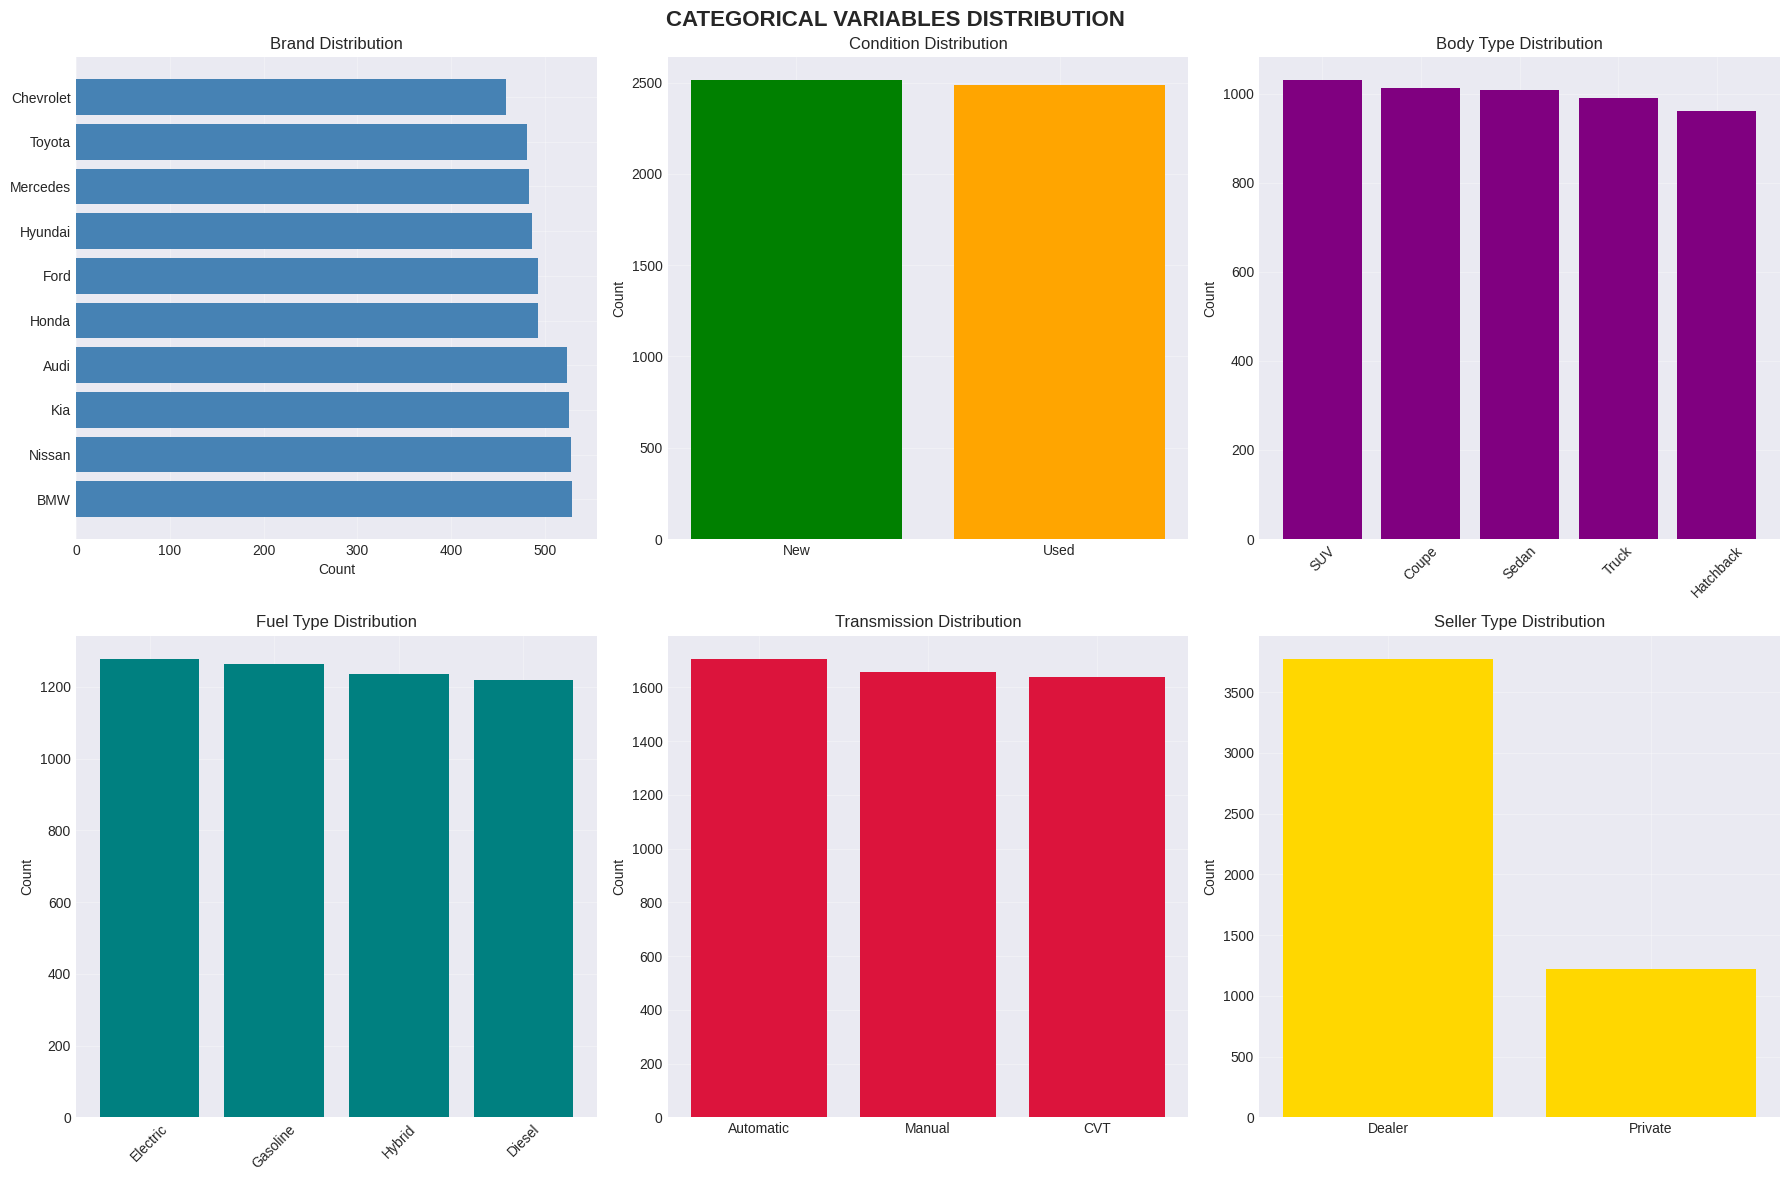

In [14]:
# Categorical Variables - Count Plots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('CATEGORICAL VARIABLES DISTRIBUTION', fontsize=16, fontweight='bold')

# Brand
brand_counts = df['brand'].value_counts()
axes[0, 0].barh(brand_counts.index, brand_counts.values, color='steelblue')
axes[0, 0].set_title('Brand Distribution')
axes[0, 0].set_xlabel('Count')
axes[0, 0].grid(True, alpha=0.3)

# Condition
condition_counts = df['condition'].value_counts()
axes[0, 1].bar(condition_counts.index, condition_counts.values, color=['green', 'orange'])
axes[0, 1].set_title('Condition Distribution')
axes[0, 1].set_ylabel('Count')
axes[0, 1].grid(True, alpha=0.3)

# Body Type
body_counts = df['body_type'].value_counts()
axes[0, 2].bar(body_counts.index, body_counts.values, color='purple')
axes[0, 2].set_title('Body Type Distribution')
axes[0, 2].set_ylabel('Count')
axes[0, 2].tick_params(axis='x', rotation=45)
axes[0, 2].grid(True, alpha=0.3)

# Fuel Type
fuel_counts = df['fuel_type'].value_counts()
axes[1, 0].bar(fuel_counts.index, fuel_counts.values, color='teal')
axes[1, 0].set_title('Fuel Type Distribution')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3)

# Transmission
trans_counts = df['transmission'].value_counts()
axes[1, 1].bar(trans_counts.index, trans_counts.values, color='crimson')
axes[1, 1].set_title('Transmission Distribution')
axes[1, 1].set_ylabel('Count')
axes[1, 1].grid(True, alpha=0.3)

# Seller Type
seller_counts = df['seller_type'].value_counts()
axes[1, 2].bar(seller_counts.index, seller_counts.values, color='gold')
axes[1, 2].set_title('Seller Type Distribution')
axes[1, 2].set_ylabel('Count')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.2 Bivariate Analysis (İki Değişken Analizi)

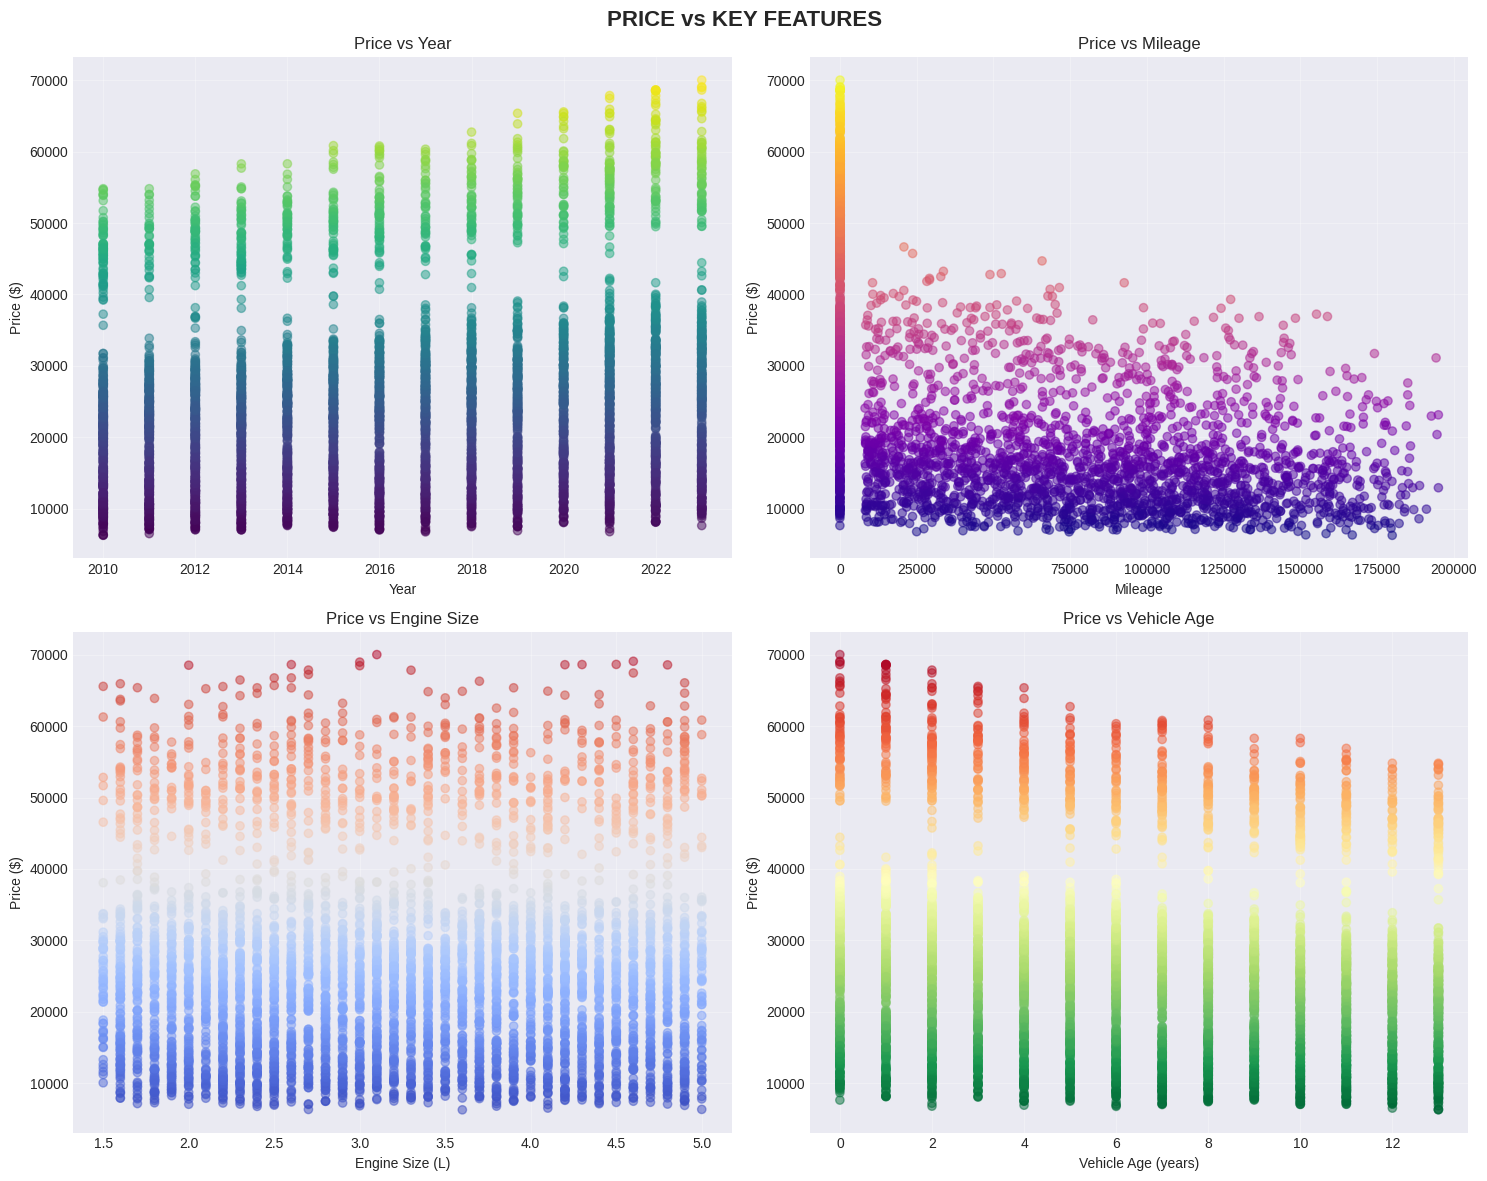

In [15]:
# Price vs Key Features
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('PRICE vs KEY FEATURES', fontsize=16, fontweight='bold')

# Price vs Year
axes[0, 0].scatter(df['year'], df['price'], alpha=0.5, c=df['price'], cmap='viridis')
axes[0, 0].set_title('Price vs Year')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Price ($)')
axes[0, 0].grid(True, alpha=0.3)

# Price vs Mileage
axes[0, 1].scatter(df['mileage'], df['price'], alpha=0.5, c=df['price'], cmap='plasma')
axes[0, 1].set_title('Price vs Mileage')
axes[0, 1].set_xlabel('Mileage')
axes[0, 1].set_ylabel('Price ($)')
axes[0, 1].grid(True, alpha=0.3)

# Price vs Engine Size
axes[1, 0].scatter(df['engine_size'], df['price'], alpha=0.5, c=df['price'], cmap='coolwarm')
axes[1, 0].set_title('Price vs Engine Size')
axes[1, 0].set_xlabel('Engine Size (L)')
axes[1, 0].set_ylabel('Price ($)')
axes[1, 0].grid(True, alpha=0.3)

# Price vs Vehicle Age
axes[1, 1].scatter(df['vehicle_age'], df['price'], alpha=0.5, c=df['price'], cmap='RdYlGn_r')
axes[1, 1].set_title('Price vs Vehicle Age')
axes[1, 1].set_xlabel('Vehicle Age (years)')
axes[1, 1].set_ylabel('Price ($)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

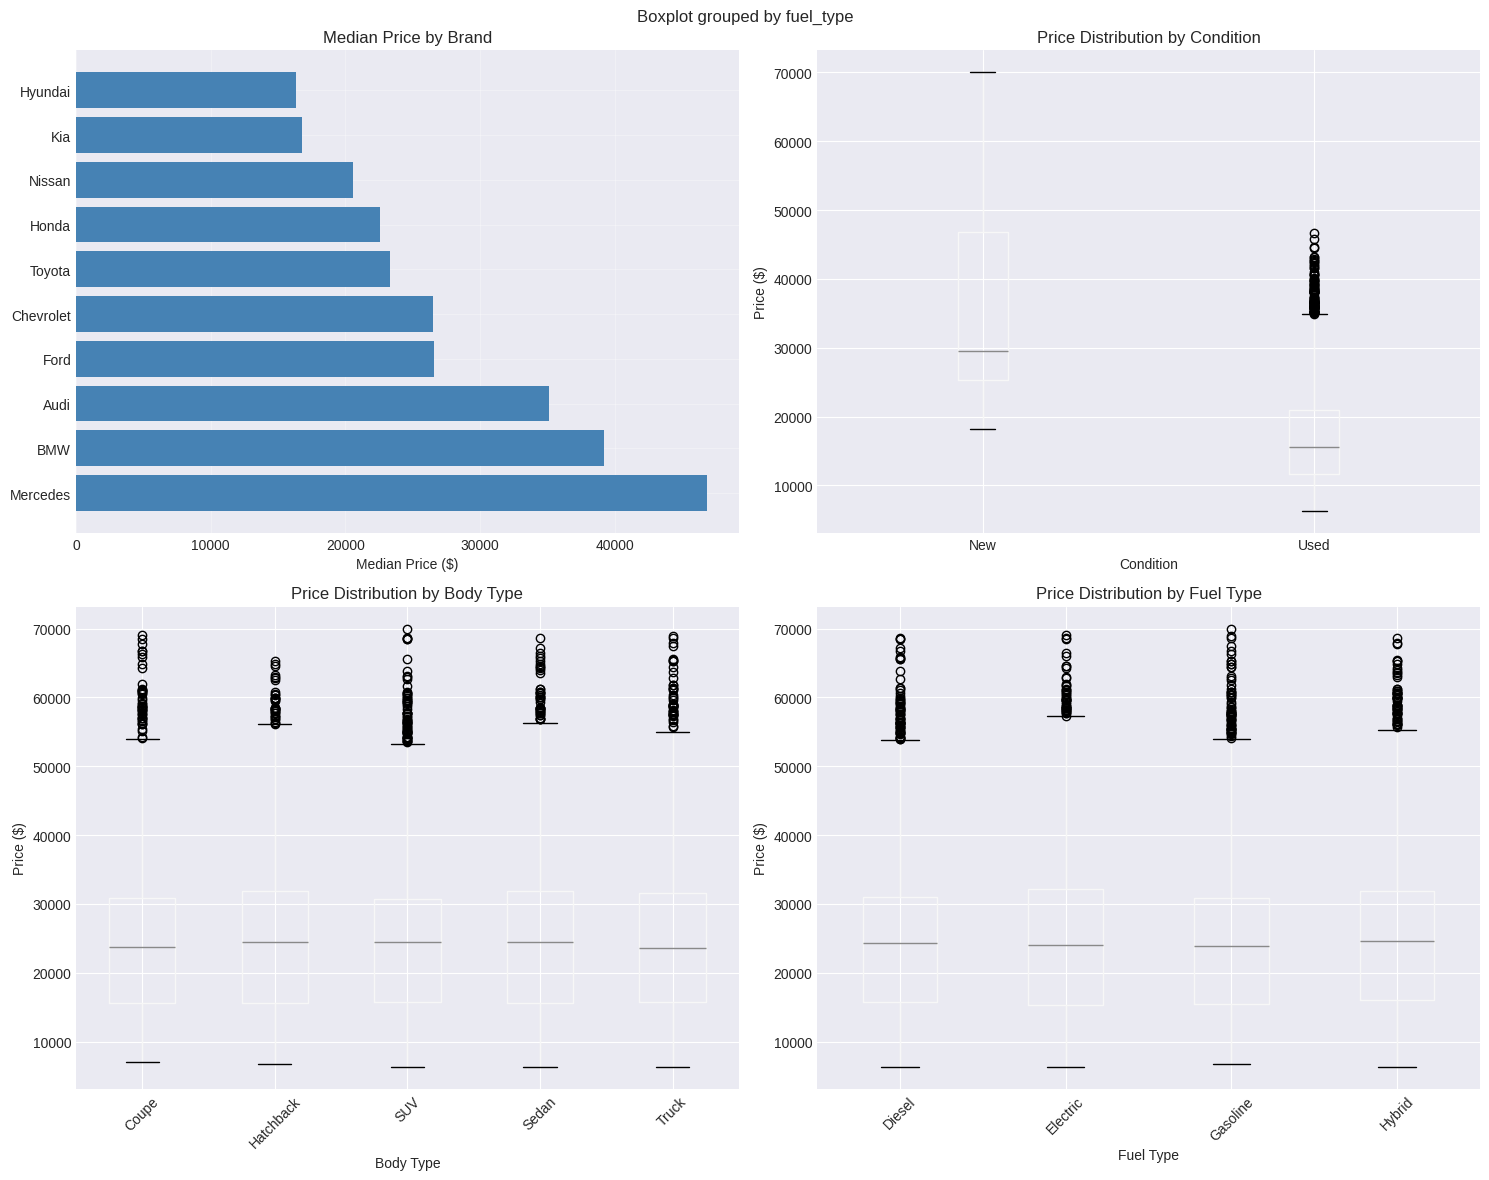

In [16]:
# Price by Categories
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('PRICE BY CATEGORICAL VARIABLES', fontsize=16, fontweight='bold')

# Price by Brand
brand_price = df.groupby('brand')['price'].median().sort_values(ascending=False)
axes[0, 0].barh(brand_price.index, brand_price.values, color='steelblue')
axes[0, 0].set_title('Median Price by Brand')
axes[0, 0].set_xlabel('Median Price ($)')
axes[0, 0].grid(True, alpha=0.3)

# Price by Condition
df.boxplot(column='price', by='condition', ax=axes[0, 1])
axes[0, 1].set_title('Price Distribution by Condition')
axes[0, 1].set_xlabel('Condition')
axes[0, 1].set_ylabel('Price ($)')
plt.sca(axes[0, 1])
plt.xticks(rotation=0)

# Price by Body Type
df.boxplot(column='price', by='body_type', ax=axes[1, 0])
axes[1, 0].set_title('Price Distribution by Body Type')
axes[1, 0].set_xlabel('Body Type')
axes[1, 0].set_ylabel('Price ($)')
plt.sca(axes[1, 0])
plt.xticks(rotation=45)

# Price by Fuel Type
df.boxplot(column='price', by='fuel_type', ax=axes[1, 1])
axes[1, 1].set_title('Price Distribution by Fuel Type')
axes[1, 1].set_xlabel('Fuel Type')
axes[1, 1].set_ylabel('Price ($)')
plt.sca(axes[1, 1])
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 5.3 Correlation Analysis (Korelasyon Analizi)

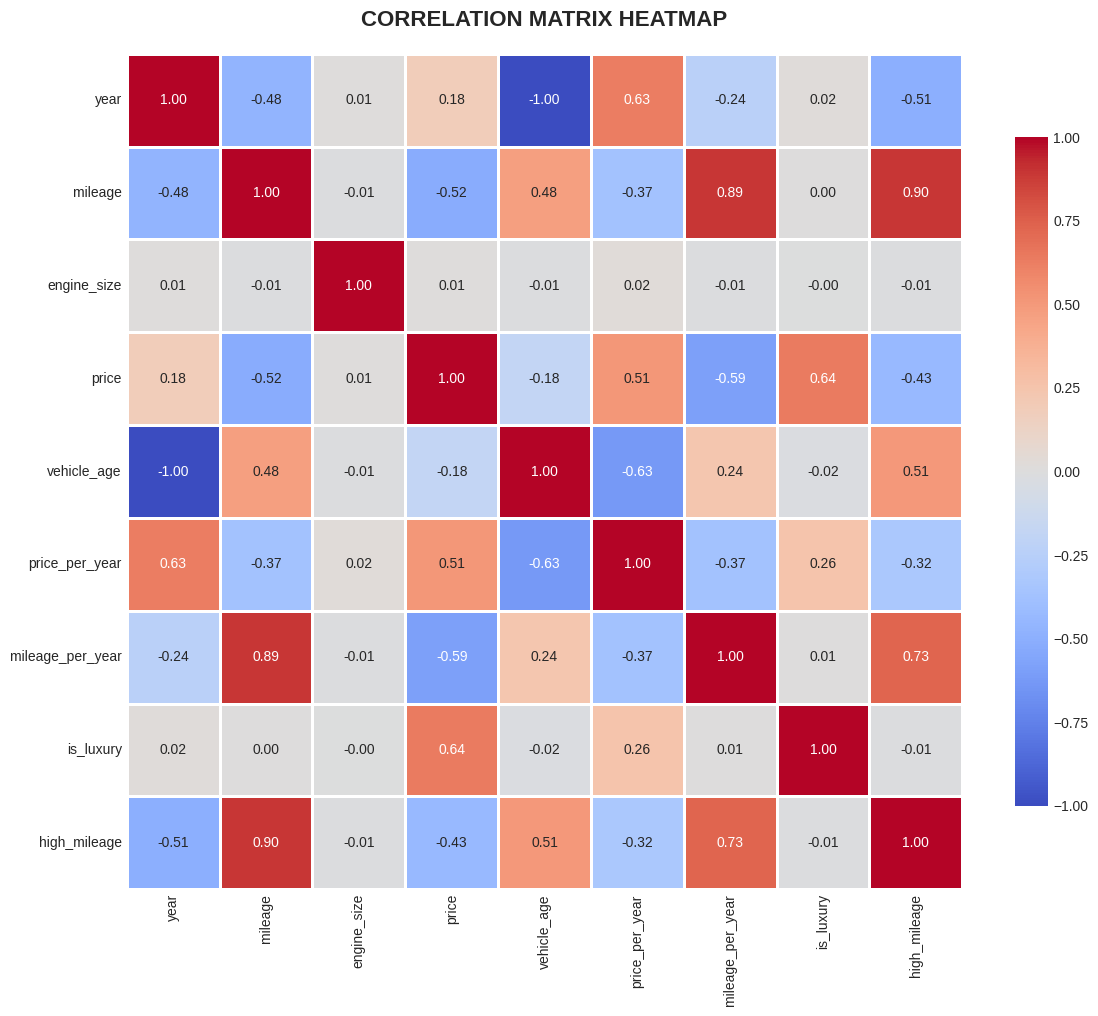


PRICE İLE EN YÜKSEK KORELASYONLAR
price               1.000000
is_luxury           0.638661
price_per_year      0.511115
year                0.182937
engine_size         0.008969
vehicle_age        -0.182937
high_mileage       -0.430464
mileage            -0.520722
mileage_per_year   -0.590627
Name: price, dtype: float64


In [17]:
# Correlation Matrix
numeric_cols = ['year', 'mileage', 'engine_size', 'price', 'vehicle_age',
                'price_per_year', 'mileage_per_year', 'is_luxury', 'high_mileage']

correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('CORRELATION MATRIX HEATMAP', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# En yüksek korelasyonlar
print("\n" + "="*80)
print("PRICE İLE EN YÜKSEK KORELASYONLAR")
print("="*80)
price_corr = correlation_matrix['price'].sort_values(ascending=False)
print(price_corr)

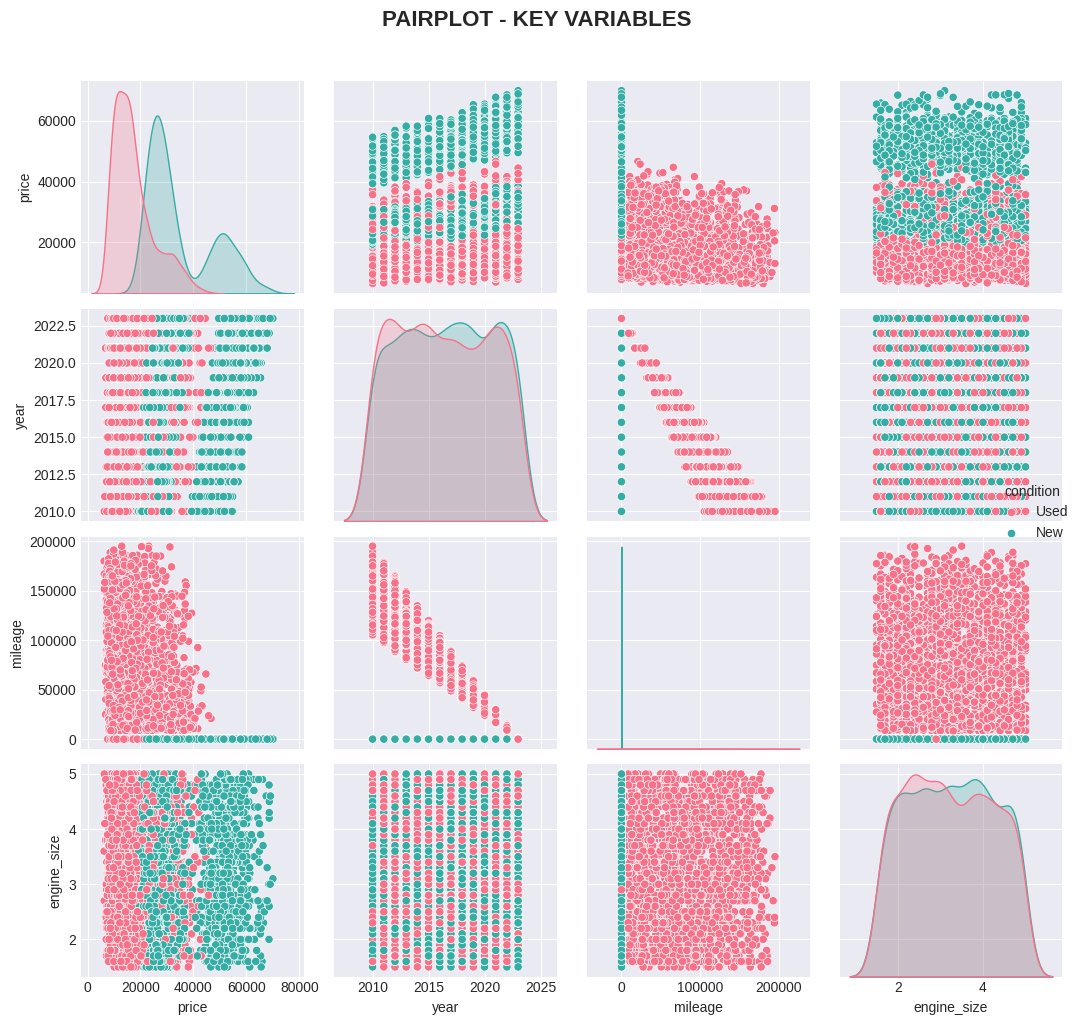

In [18]:
# Pairplot (selected variables)
selected_cols = ['price', 'year', 'mileage', 'engine_size', 'condition']
sns.pairplot(df[selected_cols], hue='condition', diag_kind='kde', palette='husl')
plt.suptitle('PAIRPLOT - KEY VARIABLES', y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.4 Advanced Visualizations

In [19]:
# Interactive Plotly - Price Distribution by Brand and Condition
fig = px.box(df, x='brand', y='price', color='condition',
             title='Interactive Price Distribution by Brand and Condition',
             labels={'price': 'Price ($)', 'brand': 'Brand'},
             template='plotly_white')
fig.update_layout(height=600, showlegend=True)
fig.show()

In [20]:
# Interactive Scatter - Price vs Mileage
fig = px.scatter(df, x='mileage', y='price', color='brand',
                 size='engine_size', hover_data=['year', 'model'],
                 title='Interactive: Price vs Mileage (colored by Brand, sized by Engine)',
                 labels={'price': 'Price ($)', 'mileage': 'Mileage'},
                 template='plotly_white')
fig.update_layout(height=600)
fig.show()

In [21]:
# 3D Scatter Plot
fig = px.scatter_3d(df, x='year', y='mileage', z='price',
                    color='brand', size='engine_size',
                    title='3D Scatter: Year vs Mileage vs Price',
                    labels={'year': 'Year', 'mileage': 'Mileage', 'price': 'Price ($)'},
                    template='plotly_white')
fig.update_layout(height=700)
fig.show()

## ⏰ 6. TIME SERIES ANALYSIS (Zaman Serisi Analizi)

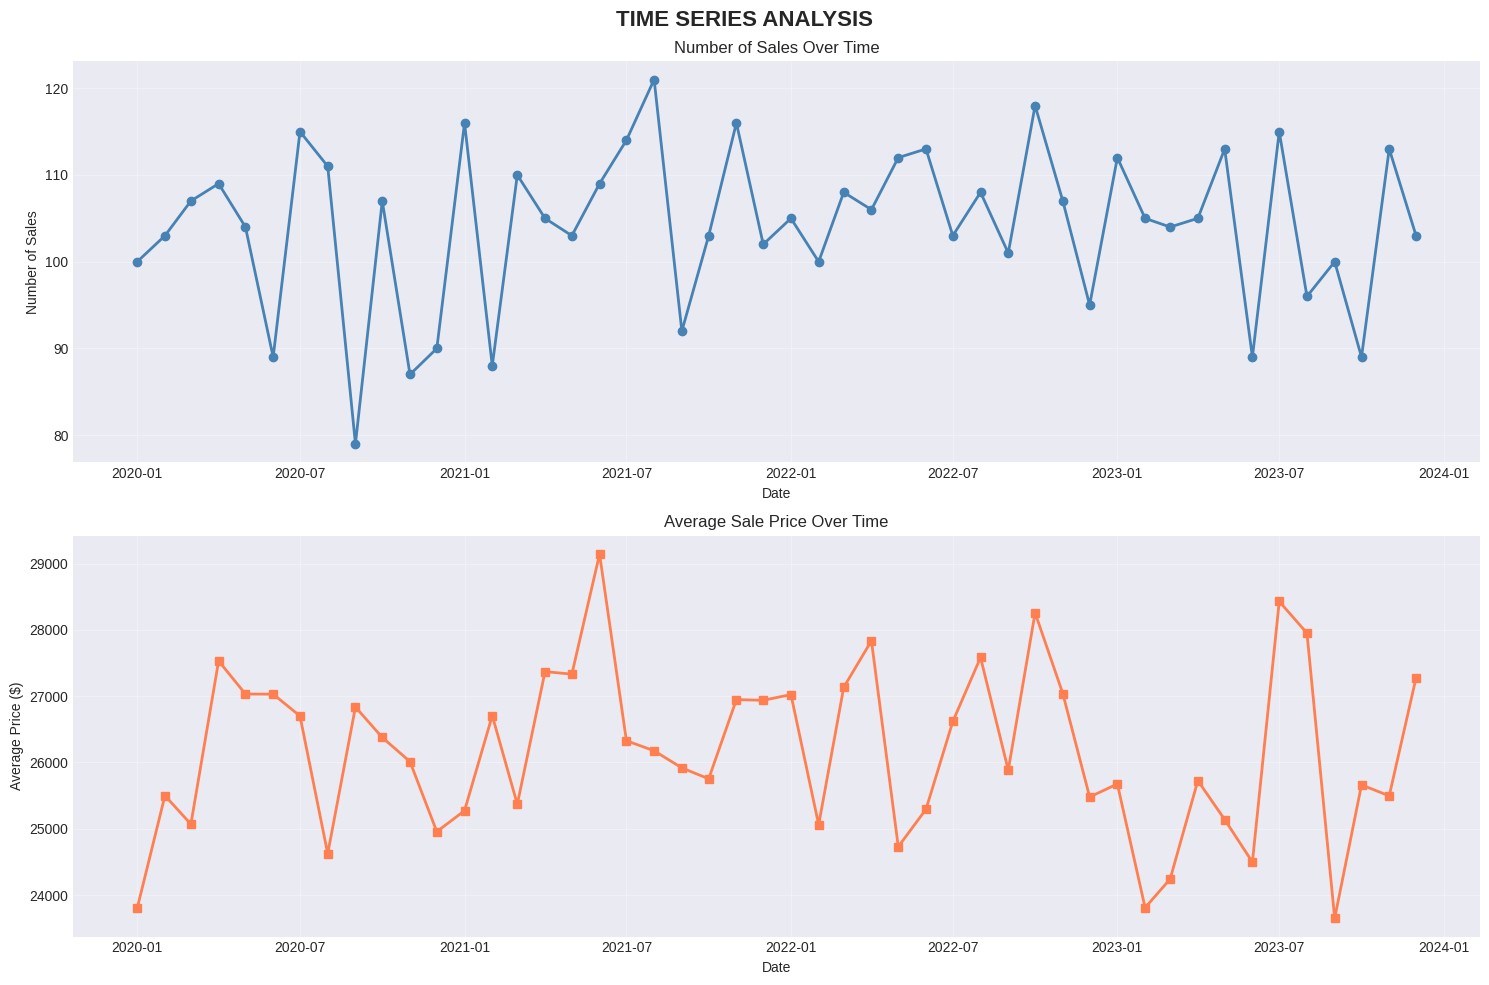

In [22]:
# Sales over time
sales_by_month = df.groupby(df['sale_date'].dt.to_period('M')).size()
sales_by_month.index = sales_by_month.index.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(15, 10))
fig.suptitle('TIME SERIES ANALYSIS', fontsize=16, fontweight='bold')

# Sales Count Over Time
axes[0].plot(sales_by_month.index, sales_by_month.values, marker='o', linewidth=2, color='steelblue')
axes[0].set_title('Number of Sales Over Time')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Number of Sales')
axes[0].grid(True, alpha=0.3)

# Average Price Over Time
price_by_month = df.groupby(df['sale_date'].dt.to_period('M'))['price'].mean()
price_by_month.index = price_by_month.index.to_timestamp()

axes[1].plot(price_by_month.index, price_by_month.values, marker='s', linewidth=2, color='coral')
axes[1].set_title('Average Sale Price Over Time')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Average Price ($)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

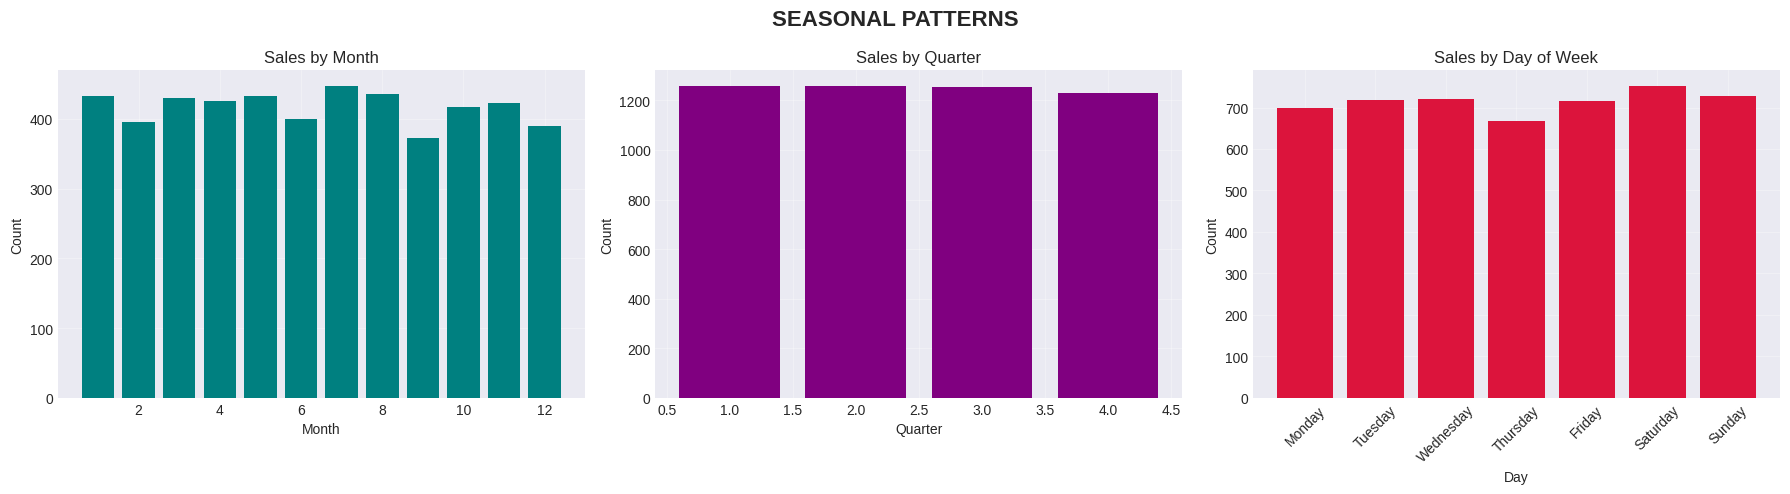

In [23]:
# Seasonal Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('SEASONAL PATTERNS', fontsize=16, fontweight='bold')

# By Month
monthly_sales = df.groupby('sale_month').size()
axes[0].bar(monthly_sales.index, monthly_sales.values, color='teal')
axes[0].set_title('Sales by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)

# By Quarter
quarterly_sales = df.groupby('sale_quarter').size()
axes[1].bar(quarterly_sales.index, quarterly_sales.values, color='purple')
axes[1].set_title('Sales by Quarter')
axes[1].set_xlabel('Quarter')
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3)

# By Day of Week
dow_sales = df.groupby('sale_day_of_week').size()
dow_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
axes[2].bar(range(7), [dow_sales.get(i, 0) for i in range(7)], color='crimson')
axes[2].set_title('Sales by Day of Week')
axes[2].set_xlabel('Day')
axes[2].set_ylabel('Count')
axes[2].set_xticks(range(7))
axes[2].set_xticklabels(dow_names, rotation=45)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 🔬 7. STATISTICAL TESTING (İstatistiksel Testler)

In [24]:
# Normality Tests
print("="*80)
print("NORMALITY TESTS FOR PRICE")
print("="*80)

# Shapiro-Wilk Test (sample of 5000)
sample_price = df['price'].sample(min(5000, len(df)), random_state=42)
stat_shapiro, p_shapiro = shapiro(sample_price)
print(f"\nShapiro-Wilk Test:")
print(f"  Statistic: {stat_shapiro:.4f}")
print(f"  P-value: {p_shapiro:.4f}")
print(f"  Result: {'Normal distribution' if p_shapiro > 0.05 else 'NOT normal distribution'}")

# Kolmogorov-Smirnov Test
stat_ks, p_ks = kstest(df['price'], 'norm', args=(df['price'].mean(), df['price'].std()))
print(f"\nKolmogorov-Smirnov Test:")
print(f"  Statistic: {stat_ks:.4f}")
print(f"  P-value: {p_ks:.4f}")
print(f"  Result: {'Normal distribution' if p_ks > 0.05 else 'NOT normal distribution'}")

NORMALITY TESTS FOR PRICE

Shapiro-Wilk Test:
  Statistic: 0.9158
  P-value: 0.0000
  Result: NOT normal distribution

Kolmogorov-Smirnov Test:
  Statistic: 0.1032
  P-value: 0.0000
  Result: NOT normal distribution


In [25]:
# T-Test: New vs Used Cars Price Comparison
print("="*80)
print("INDEPENDENT T-TEST: NEW vs USED CARS")
print("="*80)

new_prices = df[df['condition'] == 'New']['price']
used_prices = df[df['condition'] == 'Used']['price']

t_stat, p_value = stats.ttest_ind(new_prices, used_prices)

print(f"\nNew Cars - Mean Price: ${new_prices.mean():,.2f}")
print(f"Used Cars - Mean Price: ${used_prices.mean():,.2f}")
print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"\nResult: {'Significant difference' if p_value < 0.05 else 'No significant difference'} (α=0.05)")

INDEPENDENT T-TEST: NEW vs USED CARS

New Cars - Mean Price: $34,852.00
Used Cars - Mean Price: $17,429.28

T-statistic: 58.7642
P-value: 0.0000

Result: Significant difference (α=0.05)


In [26]:
# ANOVA: Price differences across brands
print("="*80)
print("ONE-WAY ANOVA: PRICE DIFFERENCES ACROSS BRANDS")
print("="*80)

brand_groups = [df[df['brand'] == brand]['price'].values for brand in df['brand'].unique()]
f_stat, p_value_anova = stats.f_oneway(*brand_groups)

print(f"\nF-statistic: {f_stat:.4f}")
print(f"P-value: {p_value_anova:.4f}")
print(f"\nResult: {'Significant difference' if p_value_anova < 0.05 else 'No significant difference'} across brands (α=0.05)")

ONE-WAY ANOVA: PRICE DIFFERENCES ACROSS BRANDS

F-statistic: 454.3196
P-value: 0.0000

Result: Significant difference across brands (α=0.05)


In [27]:
# Chi-Square Test: Brand vs Body Type
print("="*80)
print("CHI-SQUARE TEST: BRAND vs BODY TYPE")
print("="*80)

contingency_table = pd.crosstab(df['brand'], df['body_type'])
chi2, p_chi, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-square statistic: {chi2:.4f}")
print(f"P-value: {p_chi:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"\nResult: {'Significant association' if p_chi < 0.05 else 'No significant association'} (α=0.05)")

CHI-SQUARE TEST: BRAND vs BODY TYPE

Chi-square statistic: 29.6737
P-value: 0.7625
Degrees of freedom: 36

Result: No significant association (α=0.05)


In [28]:
# Pearson Correlation Test
print("="*80)
print("PEARSON CORRELATION TESTS")
print("="*80)

# Price vs Year
corr_py, p_py = stats.pearsonr(df['year'], df['price'])
print(f"\nPrice vs Year:")
print(f"  Correlation: {corr_py:.4f}")
print(f"  P-value: {p_py:.4f}")
print(f"  Result: {'Significant correlation' if p_py < 0.05 else 'No significant correlation'}")

# Price vs Mileage
corr_pm, p_pm = stats.pearsonr(df['mileage'], df['price'])
print(f"\nPrice vs Mileage:")
print(f"  Correlation: {corr_pm:.4f}")
print(f"  P-value: {p_pm:.4f}")
print(f"  Result: {'Significant correlation' if p_pm < 0.05 else 'No significant correlation'}")

PEARSON CORRELATION TESTS

Price vs Year:
  Correlation: 0.1829
  P-value: 0.0000
  Result: Significant correlation

Price vs Mileage:
  Correlation: -0.5207
  P-value: 0.0000
  Result: Significant correlation


## 🤖 8. MACHINE LEARNING - PRICE PREDICTION

### 8.1 Data Preparation

In [29]:
# Prepare data for ML
print("🔧 Veri ML için hazırlanıyor...\n")

# Select features
ml_df = df.copy()

# Encode categorical variables
label_encoders = {}
categorical_features = ['brand', 'model', 'condition', 'color', 'body_type',
                        'fuel_type', 'transmission', 'seller_type', 'state']

for col in categorical_features:
    le = LabelEncoder()
    ml_df[col + '_encoded'] = le.fit_transform(ml_df[col])
    label_encoders[col] = le

# Select features for modeling
feature_cols = ['year', 'mileage', 'engine_size', 'vehicle_age',
                'brand_encoded', 'condition_encoded', 'body_type_encoded',
                'fuel_type_encoded', 'transmission_encoded', 'seller_type_encoded',
                'is_luxury', 'high_mileage']

X = ml_df[feature_cols]
y = ml_df['price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Training set: {X_train.shape}")
print(f"✅ Test set: {X_test.shape}")
print(f"\nFeatures used: {feature_cols}")

🔧 Veri ML için hazırlanıyor...

✅ Training set: (4000, 12)
✅ Test set: (1000, 12)

Features used: ['year', 'mileage', 'engine_size', 'vehicle_age', 'brand_encoded', 'condition_encoded', 'body_type_encoded', 'fuel_type_encoded', 'transmission_encoded', 'seller_type_encoded', 'is_luxury', 'high_mileage']


### 8.2 Model Training & Evaluation

In [30]:
# Train multiple models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, max_depth=15),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=5)
}

results = {}

print("="*80)
print("MODEL TRAINING AND EVALUATION")
print("="*80)

for name, model in models.items():
    print(f"\n🔄 Training {name}...")

    # Train
    if name in ['Linear Regression', 'Ridge Regression', 'Lasso Regression']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    # Evaluate
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'model': model,
        'predictions': y_pred
    }

    print(f"  ✅ RMSE: ${rmse:,.2f}")
    print(f"  ✅ MAE: ${mae:,.2f}")
    print(f"  ✅ R² Score: {r2:.4f}")

# Results comparison
print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
results_df = pd.DataFrame(results).T[['RMSE', 'MAE', 'R2']]
results_df = results_df.sort_values('R2', ascending=False)
print(results_df)

MODEL TRAINING AND EVALUATION

🔄 Training Linear Regression...
  ✅ RMSE: $5,065.93
  ✅ MAE: $3,969.19
  ✅ R² Score: 0.8522

🔄 Training Ridge Regression...
  ✅ RMSE: $5,066.15
  ✅ MAE: $3,969.13
  ✅ R² Score: 0.8522

🔄 Training Lasso Regression...
  ✅ RMSE: $5,066.00
  ✅ MAE: $3,969.12
  ✅ R² Score: 0.8522

🔄 Training Decision Tree...
  ✅ RMSE: $4,295.98
  ✅ MAE: $3,088.01
  ✅ R² Score: 0.8937

🔄 Training Random Forest...
  ✅ RMSE: $3,583.60
  ✅ MAE: $2,700.94
  ✅ R² Score: 0.9260

🔄 Training Gradient Boosting...
  ✅ RMSE: $3,622.94
  ✅ MAE: $2,721.62
  ✅ R² Score: 0.9244

MODEL COMPARISON
                          RMSE          MAE        R2
Random Forest      3583.595938  2700.940553  0.926027
Gradient Boosting  3622.935113  2721.615042  0.924394
Decision Tree      4295.979579  3088.006674  0.893694
Linear Regression  5065.930189  3969.185042  0.852174
Lasso Regression   5066.001926  3969.121452   0.85217
Ridge Regression   5066.154841  3969.132081  0.852161


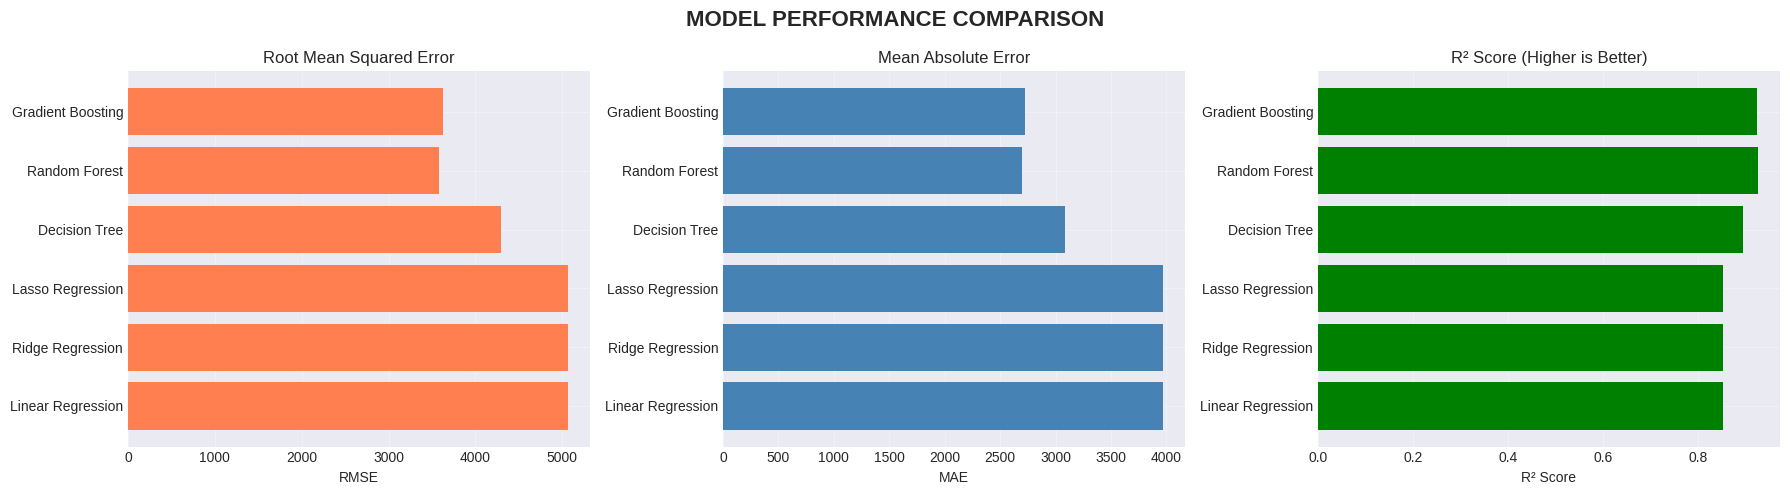

In [31]:
# Visualize model comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('MODEL PERFORMANCE COMPARISON', fontsize=16, fontweight='bold')

models_names = list(results.keys())
rmse_values = [results[m]['RMSE'] for m in models_names]
mae_values = [results[m]['MAE'] for m in models_names]
r2_values = [results[m]['R2'] for m in models_names]

# RMSE
axes[0].barh(models_names, rmse_values, color='coral')
axes[0].set_xlabel('RMSE')
axes[0].set_title('Root Mean Squared Error')
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].barh(models_names, mae_values, color='steelblue')
axes[1].set_xlabel('MAE')
axes[1].set_title('Mean Absolute Error')
axes[1].grid(True, alpha=0.3)

# R2
axes[2].barh(models_names, r2_values, color='green')
axes[2].set_xlabel('R² Score')
axes[2].set_title('R² Score (Higher is Better)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 8.3 Best Model Analysis

BEST MODEL: Random Forest

Performance Metrics:
  RMSE: $3,583.60
  MAE: $2,700.94
  R² Score: 0.9260


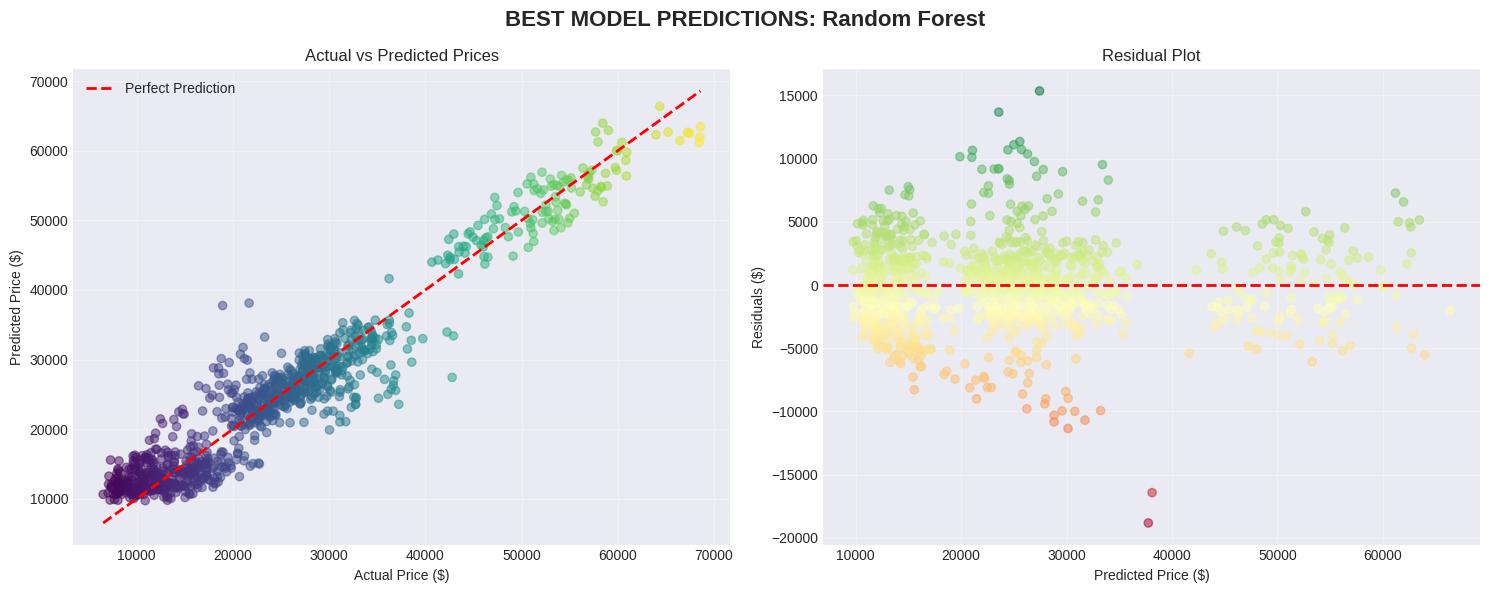

In [32]:
# Get best model
best_model_name = results_df.index[0]
best_model = results[best_model_name]['model']
best_predictions = results[best_model_name]['predictions']

print("="*80)
print(f"BEST MODEL: {best_model_name}")
print("="*80)
print(f"\nPerformance Metrics:")
print(f"  RMSE: ${results[best_model_name]['RMSE']:,.2f}")
print(f"  MAE: ${results[best_model_name]['MAE']:,.2f}")
print(f"  R² Score: {results[best_model_name]['R2']:.4f}")

# Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f'BEST MODEL PREDICTIONS: {best_model_name}', fontsize=16, fontweight='bold')

# Scatter plot
axes[0].scatter(y_test, best_predictions, alpha=0.5, c=y_test, cmap='viridis')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title('Actual vs Predicted Prices')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals
residuals = y_test - best_predictions
axes[1].scatter(best_predictions, residuals, alpha=0.5, c=residuals, cmap='RdYlGn')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Price ($)')
axes[1].set_ylabel('Residuals ($)')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

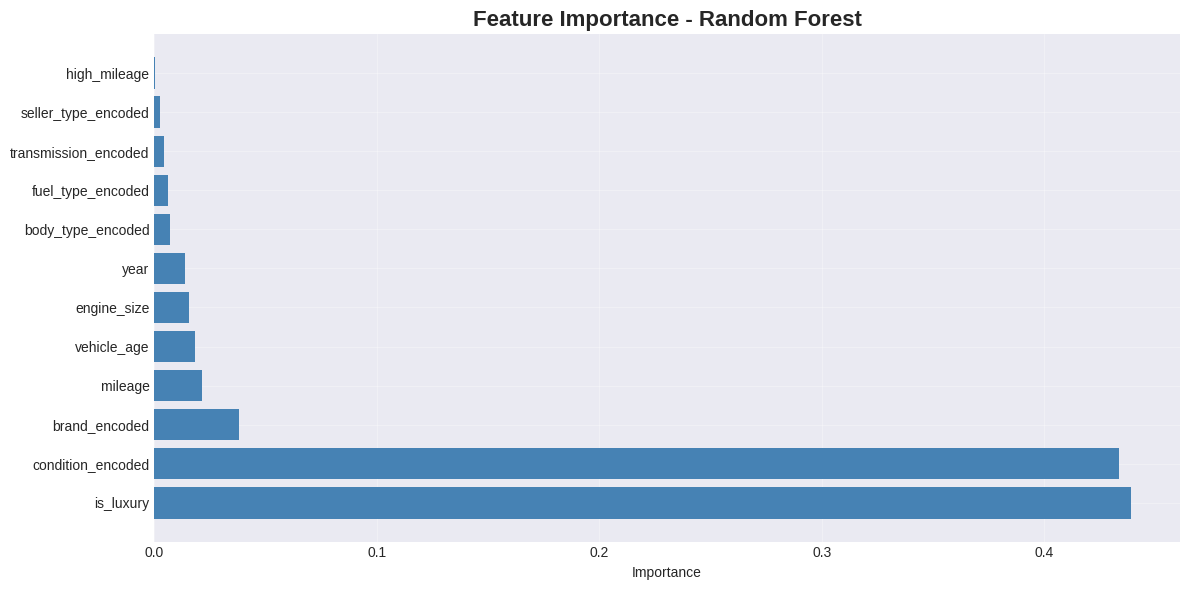


Top 5 Most Important Features:
              Feature  Importance
10          is_luxury    0.439036
5   condition_encoded    0.433784
4       brand_encoded    0.038148
1             mileage    0.021570
3         vehicle_age    0.018316


In [33]:
# Feature Importance (for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(12, 6))
    plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
    plt.xlabel('Importance')
    plt.title(f'Feature Importance - {best_model_name}', fontsize=16, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\nTop 5 Most Important Features:")
    print(feature_importance.head())

### 8.4 Cross-Validation

CROSS-VALIDATION: Random Forest

Cross-Validation R² Scores: [0.933048   0.92847826 0.92176216 0.92470462 0.91576869]
Mean CV R² Score: 0.9248
Std Dev: 0.0059


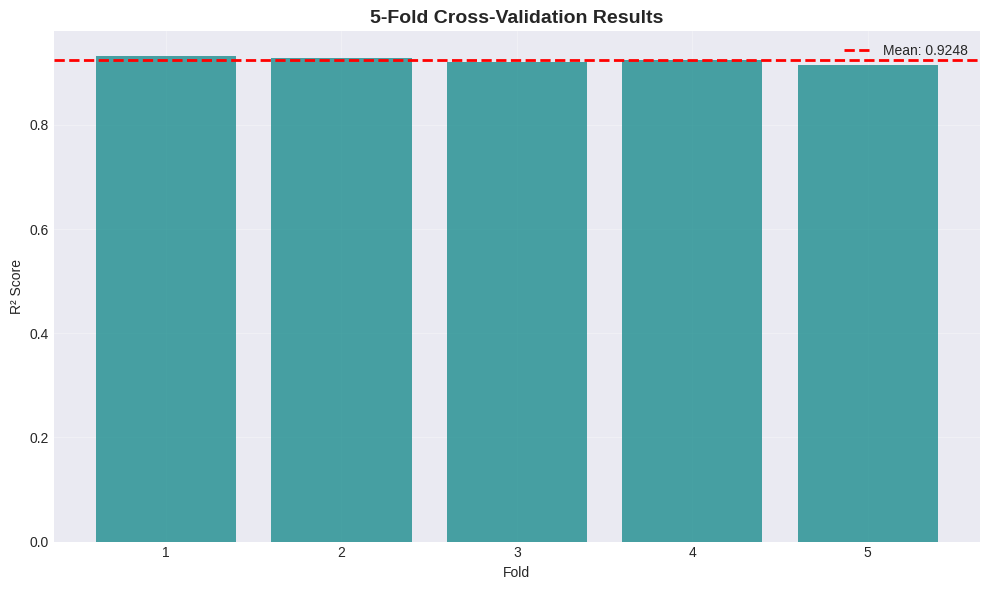

In [34]:
# Cross-validation for best model
print("="*80)
print(f"CROSS-VALIDATION: {best_model_name}")
print("="*80)

if best_model_name in ['Linear Regression', 'Ridge Regression', 'Lasso Regression']:
    cv_scores = cross_val_score(best_model, X_train_scaled, y_train,
                                cv=5, scoring='r2')
else:
    cv_scores = cross_val_score(best_model, X_train, y_train,
                                cv=5, scoring='r2')

print(f"\nCross-Validation R² Scores: {cv_scores}")
print(f"Mean CV R² Score: {cv_scores.mean():.4f}")
print(f"Std Dev: {cv_scores.std():.4f}")

# Visualization
plt.figure(figsize=(10, 6))
plt.bar(range(1, 6), cv_scores, color='teal', alpha=0.7)
plt.axhline(y=cv_scores.mean(), color='r', linestyle='--', linewidth=2,
            label=f'Mean: {cv_scores.mean():.4f}')
plt.xlabel('Fold')
plt.ylabel('R² Score')
plt.title('5-Fold Cross-Validation Results', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 🎯 9. CLUSTERING ANALYSIS

🔄 K-Means Clustering yapılıyor...



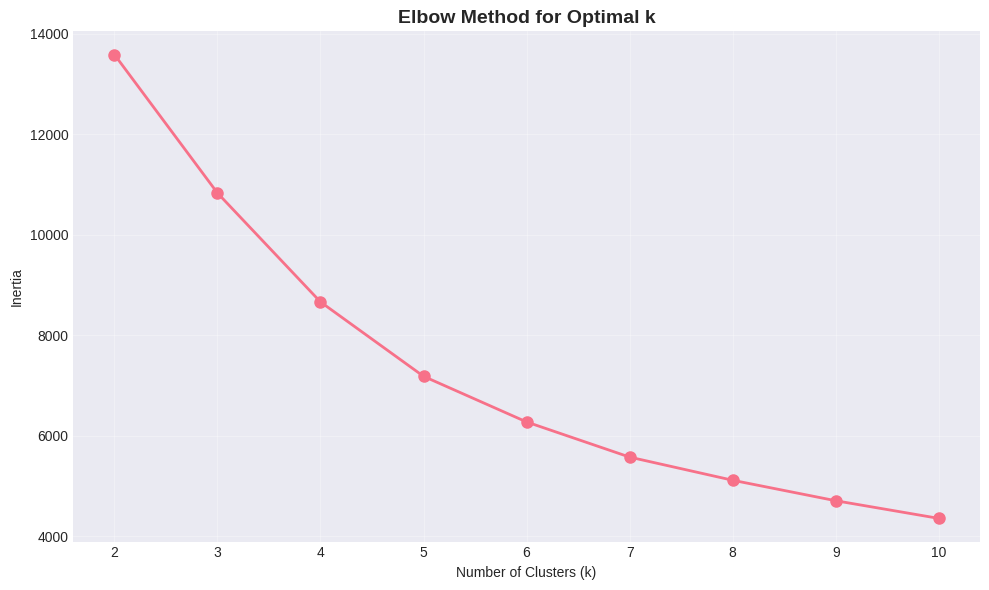

In [35]:
# K-Means Clustering
print("🔄 K-Means Clustering yapılıyor...\n")

# Select features for clustering
cluster_features = ['price', 'mileage', 'engine_size', 'vehicle_age']
X_cluster = df[cluster_features].copy()

# Standardize
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

# Elbow method
inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, marker='o', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [36]:
# Apply K-Means with optimal k
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_cluster_scaled)

print(f"✅ K-Means clustering completed with k={optimal_k}\n")
print("Cluster Distribution:")
print(df['cluster'].value_counts().sort_index())

✅ K-Means clustering completed with k=4

Cluster Distribution:
cluster
0    1200
1    1549
2     768
3    1483
Name: count, dtype: int64


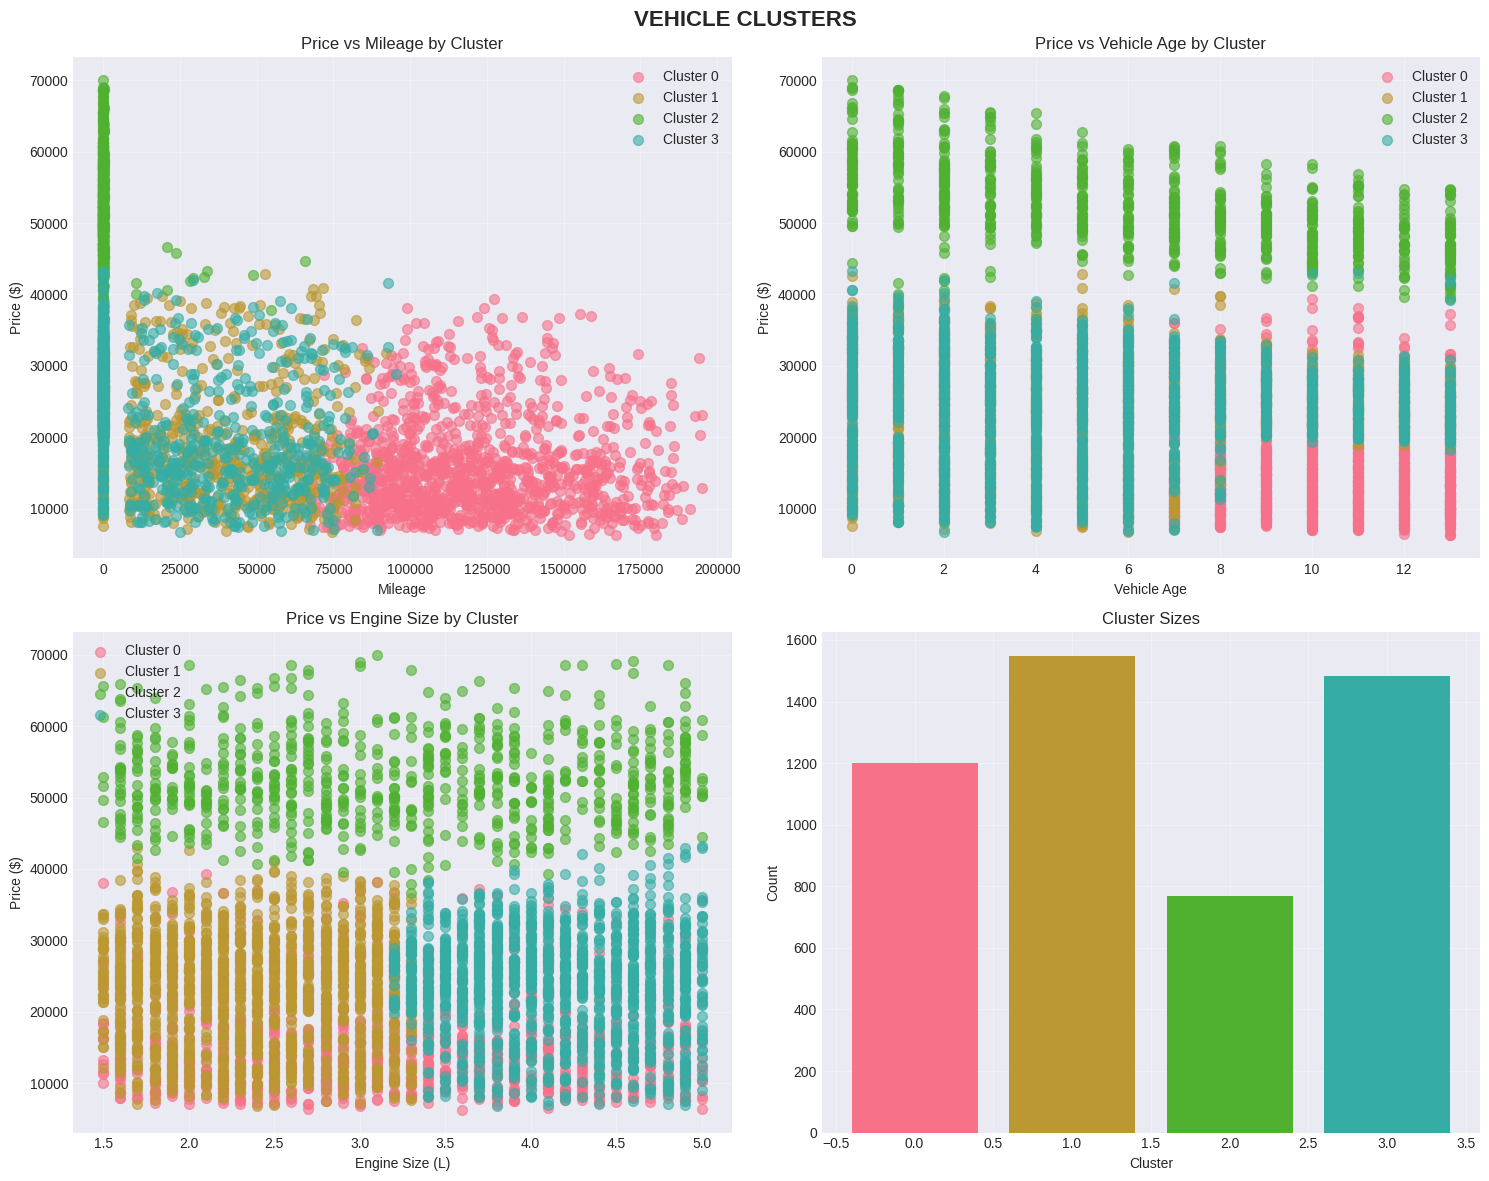

In [37]:
# Visualize clusters
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('VEHICLE CLUSTERS', fontsize=16, fontweight='bold')

# Price vs Mileage
for cluster in range(optimal_k):
    cluster_data = df[df['cluster'] == cluster]
    axes[0, 0].scatter(cluster_data['mileage'], cluster_data['price'],
                      label=f'Cluster {cluster}', alpha=0.6, s=50)
axes[0, 0].set_xlabel('Mileage')
axes[0, 0].set_ylabel('Price ($)')
axes[0, 0].set_title('Price vs Mileage by Cluster')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Price vs Vehicle Age
for cluster in range(optimal_k):
    cluster_data = df[df['cluster'] == cluster]
    axes[0, 1].scatter(cluster_data['vehicle_age'], cluster_data['price'],
                      label=f'Cluster {cluster}', alpha=0.6, s=50)
axes[0, 1].set_xlabel('Vehicle Age')
axes[0, 1].set_ylabel('Price ($)')
axes[0, 1].set_title('Price vs Vehicle Age by Cluster')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Engine Size vs Price
for cluster in range(optimal_k):
    cluster_data = df[df['cluster'] == cluster]
    axes[1, 0].scatter(cluster_data['engine_size'], cluster_data['price'],
                      label=f'Cluster {cluster}', alpha=0.6, s=50)
axes[1, 0].set_xlabel('Engine Size (L)')
axes[1, 0].set_ylabel('Price ($)')
axes[1, 0].set_title('Price vs Engine Size by Cluster')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Cluster sizes
cluster_counts = df['cluster'].value_counts().sort_index()
axes[1, 1].bar(cluster_counts.index, cluster_counts.values,
              color=['C0', 'C1', 'C2', 'C3'][:optimal_k])
axes[1, 1].set_xlabel('Cluster')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Cluster Sizes')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
# Cluster characteristics
print("="*80)
print("CLUSTER CHARACTERISTICS")
print("="*80)

cluster_summary = df.groupby('cluster')[cluster_features].mean()
cluster_summary

CLUSTER CHARACTERISTICS


,price,mileage,engine_size,vehicle_age
cluster,,,,
0,15674.531658,120133.981667,3.218167,10.255833
1,23428.352886,16046.907682,2.389735,4.963848
2,52462.237266,546.795573,3.252344,6.110677
3,23964.082023,14660.138570,4.139110,5.364801


## 📉 10. DIMENSIONALITY REDUCTION (PCA)

🔄 PCA Analysis yapılıyor...



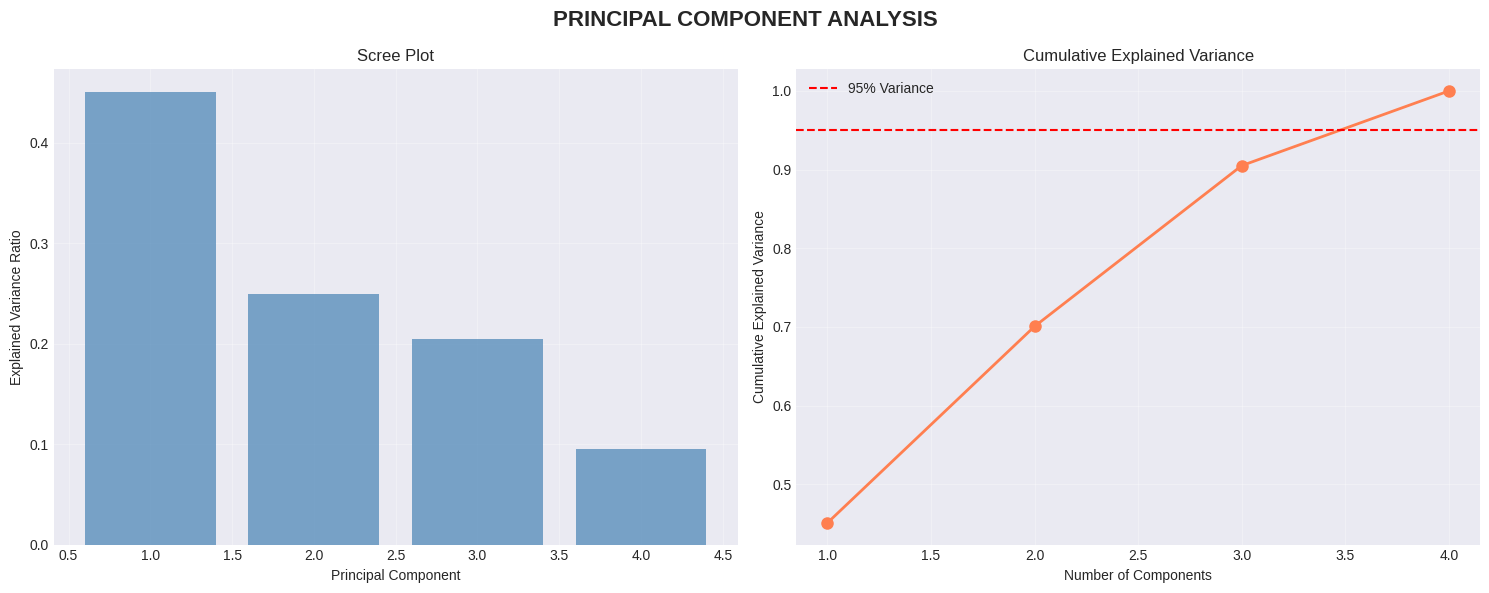


Explained Variance by Component:
  PC1: 0.4507 (0.4507 cumulative)
  PC2: 0.2499 (0.7005 cumulative)
  PC3: 0.2045 (0.9050 cumulative)
  PC4: 0.0950 (1.0000 cumulative)


In [39]:
# PCA Analysis
print("🔄 PCA Analysis yapılıyor...\n")

pca = PCA()
pca_features = pca.fit_transform(X_cluster_scaled)

# Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('PRINCIPAL COMPONENT ANALYSIS', fontsize=16, fontweight='bold')

# Scree plot
axes[0].bar(range(1, len(explained_variance) + 1), explained_variance,
           color='steelblue', alpha=0.7)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot')
axes[0].grid(True, alpha=0.3)

# Cumulative variance
axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance,
            marker='o', linewidth=2, markersize=8, color='coral')
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nExplained Variance by Component:")
for i, var in enumerate(explained_variance, 1):
    print(f"  PC{i}: {var:.4f} ({cumulative_variance[i-1]:.4f} cumulative)")

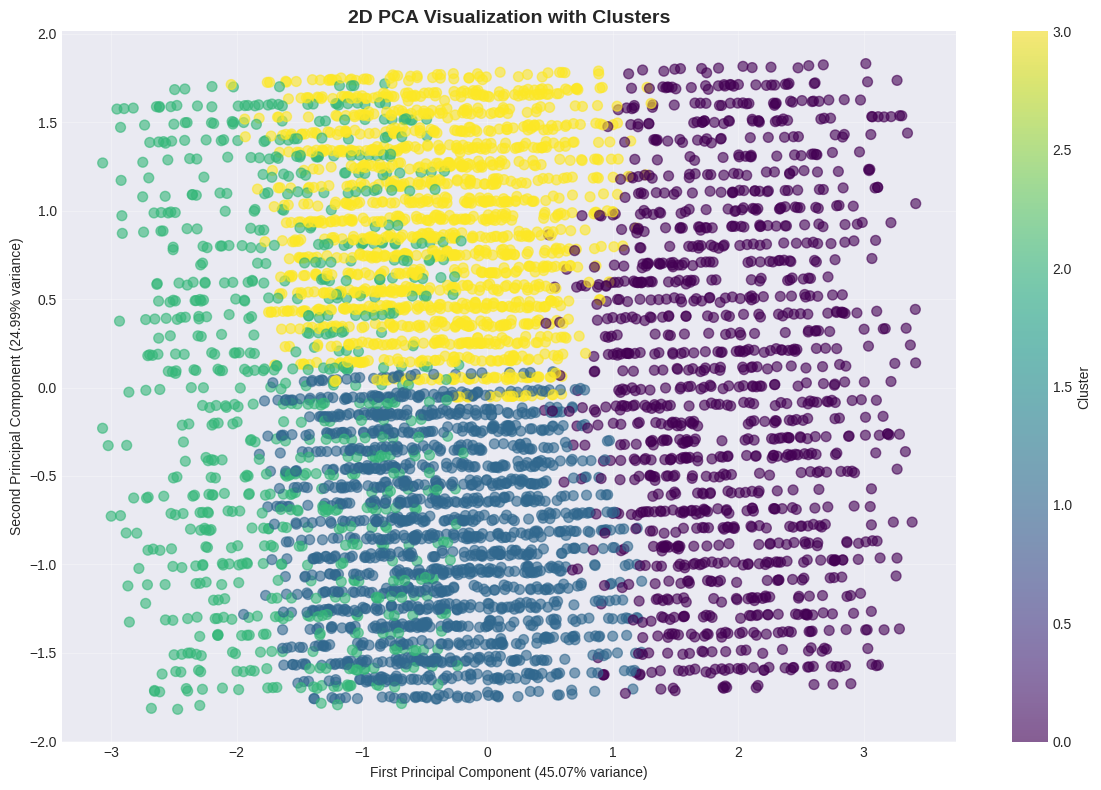

In [40]:
# 2D PCA visualization with clusters
pca_2d = PCA(n_components=2)
pca_2d_features = pca_2d.fit_transform(X_cluster_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(pca_2d_features[:, 0], pca_2d_features[:, 1],
                     c=df['cluster'], cmap='viridis', alpha=0.6, s=50)
plt.xlabel(f'First Principal Component ({pca_2d.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'Second Principal Component ({pca_2d.explained_variance_ratio_[1]:.2%} variance)')
plt.title('2D PCA Visualization with Clusters', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 💼 11. BUSINESS INSIGHTS & RECOMMENDATIONS

In [41]:
# Key Business Metrics
print("="*80)
print("KEY BUSINESS METRICS")
print("="*80)

print(f"\n📊 OVERALL METRICS:")
print(f"  Total Sales Volume: {len(df):,}")
print(f"  Total Revenue: ${df['price'].sum():,.2f}")
print(f"  Average Sale Price: ${df['price'].mean():,.2f}")
print(f"  Median Sale Price: ${df['price'].median():,.2f}")

print(f"\n🏆 TOP PERFORMING BRANDS:")
top_brands = df.groupby('brand').agg({
    'price': ['count', 'mean', 'sum']
}).round(2)
top_brands.columns = ['Sales_Count', 'Avg_Price', 'Total_Revenue']
top_brands = top_brands.sort_values('Total_Revenue', ascending=False).head(5)
print(top_brands)

print(f"\n💰 LUXURY vs NON-LUXURY:")
luxury_summary = df.groupby('is_luxury').agg({
    'price': ['count', 'mean', 'sum']
}).round(2)
luxury_summary.columns = ['Count', 'Avg_Price', 'Total_Revenue']
luxury_summary.index = ['Non-Luxury', 'Luxury']
print(luxury_summary)

print(f"\n🔧 CONDITION BREAKDOWN:")
condition_summary = df.groupby('condition').agg({
    'price': ['count', 'mean', 'sum']
}).round(2)
condition_summary.columns = ['Count', 'Avg_Price', 'Total_Revenue']
print(condition_summary)

KEY BUSINESS METRICS

📊 OVERALL METRICS:
  Total Sales Volume: 5,000
  Total Revenue: $130,929,688.47
  Average Sale Price: $26,185.94
  Median Sale Price: $24,175.96

🏆 TOP PERFORMING BRANDS:
           Sales_Count  Avg_Price  Total_Revenue
brand                                           
Mercedes           483   43787.90    21149556.83
BMW                529   38319.90    20271226.08
Audi               523   36036.74    18847213.25
Ford               493   24144.65    11903312.25
Chevrolet          458   23599.92    10808765.06

💰 LUXURY vs NON-LUXURY:
            Count  Avg_Price  Total_Revenue
Non-Luxury   3465   20392.98    70661692.31
Luxury       1535   39262.54    60267996.16

🔧 CONDITION BREAKDOWN:
           Count  Avg_Price  Total_Revenue
condition                                 
New         2513   34852.00    87583079.97
Used        2487   17429.28    43346608.50


DEPRECIATION ANALYSIS


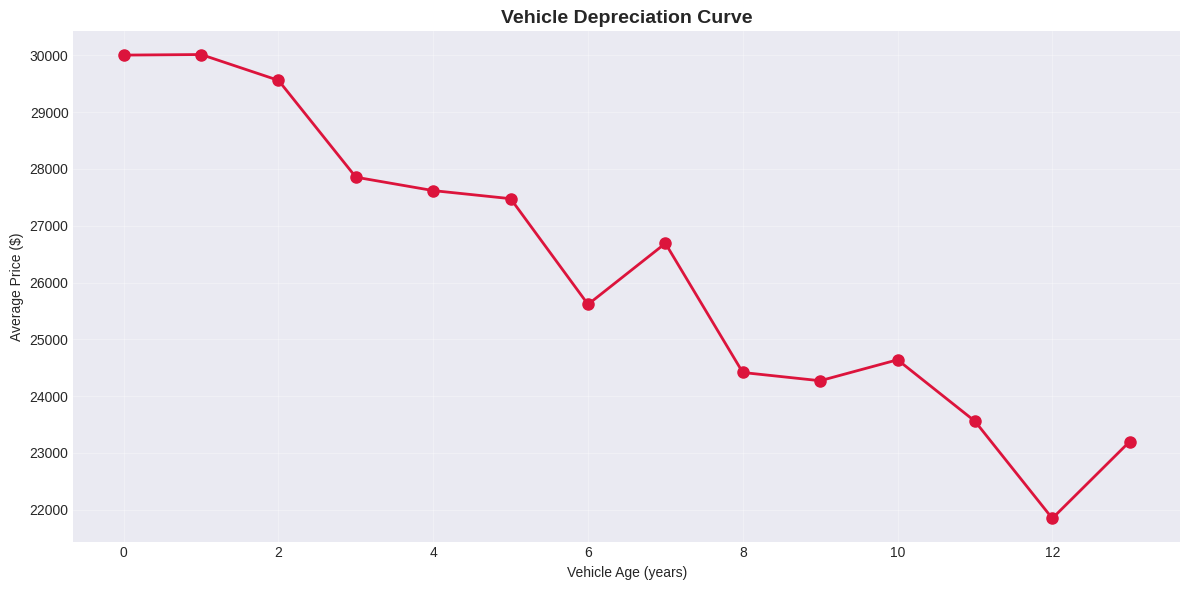


Average depreciation over 5 years: 8.45%
Annual depreciation rate: 1.69%


In [42]:
# Depreciation Analysis
print("="*80)
print("DEPRECIATION ANALYSIS")
print("="*80)

depreciation = df.groupby('vehicle_age')['price'].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(depreciation['vehicle_age'], depreciation['price'],
         marker='o', linewidth=2, markersize=8, color='crimson')
plt.xlabel('Vehicle Age (years)')
plt.ylabel('Average Price ($)')
plt.title('Vehicle Depreciation Curve', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate depreciation rate
year_1_price = depreciation[depreciation['vehicle_age'] == 1]['price'].values[0]
year_5_price = depreciation[depreciation['vehicle_age'] == 5]['price'].values[0]
depreciation_rate = (year_1_price - year_5_price) / year_1_price * 100

print(f"\nAverage depreciation over 5 years: {depreciation_rate:.2f}%")
print(f"Annual depreciation rate: {depreciation_rate/5:.2f}%")

## 📝 12. FINAL SUMMARY & CONCLUSIONS

In [43]:
print("="*80)
print("🎯 FINAL ANALYSIS SUMMARY")
print("="*80)

print("\n✅ COMPLETED ANALYSES:")
print("  1. ✓ Data Loading & Exploration")
print("  2. ✓ Data Cleaning & Preprocessing")
print("  3. ✓ Feature Engineering (7+ new features)")
print("  4. ✓ Descriptive Statistics")
print("  5. ✓ Exploratory Data Analysis (EDA)")
print("  6. ✓ Univariate & Bivariate Analysis")
print("  7. ✓ Correlation Analysis")
print("  8. ✓ Time Series Analysis")
print("  9. ✓ Statistical Testing (Normality, T-test, ANOVA, Chi-square, Correlation)")
print(" 10. ✓ Machine Learning (6 different models)")
print(" 11. ✓ Model Evaluation & Cross-Validation")
print(" 12. ✓ K-Means Clustering")
print(" 13. ✓ PCA (Dimensionality Reduction)")
print(" 14. ✓ Business Insights & Metrics")

print("\n🏆 KEY FINDINGS:")
print(f"  • Best ML Model: {best_model_name}")
print(f"  • Best R² Score: {results[best_model_name]['R2']:.4f}")
print(f"  • Optimal Clusters: {optimal_k}")
print(f"  • Top Brand by Revenue: {top_brands.index[0]}")
print(f"  • Average Vehicle Depreciation: {depreciation_rate:.2f}% over 5 years")

print("\n💡 RECOMMENDATIONS:")
print("  1. Focus on high-performing brands and models")
print("  2. Leverage ML models for dynamic pricing strategies")
print("  3. Consider seasonal patterns in sales planning")
print("  4. Optimize inventory based on cluster analysis")
print("  5. Account for depreciation rates in pricing used vehicles")

print("\n" + "="*80)
print("✅ COMPREHENSIVE DATA SCIENCE ANALYSIS COMPLETED!")
print("="*80)

🎯 FINAL ANALYSIS SUMMARY

✅ COMPLETED ANALYSES:
  1. ✓ Data Loading & Exploration
  2. ✓ Data Cleaning & Preprocessing
  3. ✓ Feature Engineering (7+ new features)
  4. ✓ Descriptive Statistics
  5. ✓ Exploratory Data Analysis (EDA)
  6. ✓ Univariate & Bivariate Analysis
  7. ✓ Correlation Analysis
  8. ✓ Time Series Analysis
  9. ✓ Statistical Testing (Normality, T-test, ANOVA, Chi-square, Correlation)
 10. ✓ Machine Learning (6 different models)
 11. ✓ Model Evaluation & Cross-Validation
 12. ✓ K-Means Clustering
 13. ✓ PCA (Dimensionality Reduction)
 14. ✓ Business Insights & Metrics

🏆 KEY FINDINGS:
  • Best ML Model: Random Forest
  • Best R² Score: 0.9260
  • Optimal Clusters: 4
  • Top Brand by Revenue: Mercedes
  • Average Vehicle Depreciation: 8.45% over 5 years

💡 RECOMMENDATIONS:
  1. Focus on high-performing brands and models
  2. Leverage ML models for dynamic pricing strategies
  3. Consider seasonal patterns in sales planning
  4. Optimize inventory based on cluster anal